In [1]:
import numpy as np
import gurobipy
import cvxpy as cp
import pandas as pd
from matplotlib import pyplot as plt
import os
import json
import random
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
import time
import warnings
warnings.filterwarnings('ignore')

## Data Reading
1. Electricity Price
2. 

In [2]:
# Data Preparation
data = pd.read_csv(r"23solar_data15.csv", encoding="gbk")
load_data = pd.read_csv(r"building data/2zonesupermarket15.csv")
data["hour"] = np.sin(2 * np.pi * (data["hour"] * 60 + data["min"]) / (24 * 60))
mdays = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
cum_before = np.insert(np.cumsum(mdays), 0, 0)
months = data['month'].to_numpy(dtype=int)
days = data['day'].to_numpy(dtype=int)
data['doy'] = np.sin((cum_before[months-1] + days) * 2 * np.pi / 365)

# Enforce there are no quantile crossings
def enforce_non_crossing(preds, quantiles=[0.1, 0.5, 0.9]):
    # preds: dict horizon -> {quantile: value}
    for h in sorted(preds.keys()):
        # ensure the quantile keys are in ascending order
        vals = [preds[h][q] for q in quantiles]
        # monotone non-decreasing across quantiles
        monotone = []
        cur = vals[0]
        monotone.append(cur)
        for v in vals[1:]:
            cur = max(cur, v)
            monotone.append(cur)
        # write back
        for i, q in enumerate(quantiles):
            preds[h][q] = monotone[i]
    return preds


# Load models from manifest
def load_models_from_manifest(model_dir='models'):
    manifest_path = os.path.join(model_dir, 'manifest.json')
    with open(manifest_path, 'r') as f:
        manifest = json.load(f)

    horizons = manifest['horizons']
    quantiles = manifest['quantiles']

    boosters = []
    for hi, h in enumerate(horizons):
        row = []
        for qi, q in enumerate(quantiles):
            path = manifest['models'][hi * len(quantiles) + qi]['path']
            b = xgb.Booster()
            b.load_model(path)
            row.append(b)
        boosters.append(row)
    return boosters, manifest


# Inference: predict quantiles for new data
def predict_quantiles_from_boosters(X_new, boosters, quantiles=[0.1, 0.5, 0.9]):
    """
    X_new: shape (1, F) or (K, F)
    boosters: list of horizons x quantiles boosters
    Returns: dict horizon -> {quantile: value}
    """
    dtest = xgb.DMatrix(X_new)
    results = {}
    for hi, horizon_boosters in enumerate(boosters):
        h = hi + 1
        row = {}
        for qi, q in enumerate(quantiles):
            preds = horizon_boosters[qi].predict(dtest)
            row[q] = float(preds.ravel()[0])
        results[h] = row
    return results

T_c = 4 * 2
horizons = [i for i in range(T_c)]
qs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# load pre-trained model
temp_models, temp_manifest = load_models_from_manifest('15temp_models')
pv_models, pv_manifest = load_models_from_manifest('15pv_models')
load_models, load_manifest = load_models_from_manifest('15load_models')

# Formulate the input data window
def build_x_windows(df, x_features, y_features, ctx=24*4, H=2*4):
    """
        X contains the historical 24 hours' feature data and corresponding prediction output
    """
    base_features = y_features + x_features
    arr = df[base_features].values
    X_windows = []
    for i in range(ctx, len(df)):
        curr_X = arr[i-ctx:i, :].reshape(-1)
        X_windows.append(curr_X) # This contains the last 24 hours' historical data
    return np.stack(X_windows)


# Generate scenarios for temperature 
### After change the candidate_month and the candidate_day, remember to re-run the following cells ###
candidate_month = 7
candidate_day = 6
candidate_index_start = (cum_before[candidate_month-1] + candidate_day-2) * 24 * 4
candidate_index_end = candidate_index_start + 2 * 4 * 24
mask = (data['month'] == candidate_month) & (data['day'].isin([candidate_day, candidate_day-1]))
select_data = data.loc[mask]
X_temp_features = ['hour', 'Irradiance', 'Rainfall', 'RH', 'SLP', 'WS', 'WD']
y_temp_features = ['Temp']
X_temp = build_x_windows(select_data, X_temp_features, y_temp_features)
X_pv_features = ["hour", "Irradiance", "Rainfall", "RH", "SLP", "Temp", "Vis", "WS", "WD", "doy"]
y_pv_features = ["generation"]
X_pv = build_x_windows(select_data, X_pv_features, y_pv_features)
# load forecasting only takes features including hour and outdoor temperature

select_load_data = load_data.iloc[candidate_index_start:candidate_index_end, :]
select_load_data['outdoor temperature'] = select_data['Temp'].values
X_load_features = ['outdoor temperature', 'time']
y_load_features = ['load']
X_load = build_x_windows(select_load_data, X_load_features, y_load_features)

In [3]:
# Scenario Generation at the beginning of each MPC period
def dict_to_array(dict):
    array = np.zeros((T_c, len(qs))) # next T_c hours and 9 quantiles
    for i in range(1, T_c+1):
        for j, q in enumerate(qs):
            array[i-1, j] = dict[i].get(q, np.nan)
    # print(array)
    return array


def scen_generation(t, method='Uniform'):
    """
        Use the quantiles as the candidate samples
        scens has dimension (len(qs)**2, H, 3)
    """
    np.random.seed(42)
    curr_x_temp = X_temp[t:t+1, :]
    curr_x_pv = X_pv[t:t+1, :]
    curr_x_load = X_load[t:t+1, :]
    N_sam = 50
    temp_qs = enforce_non_crossing(predict_quantiles_from_boosters(curr_x_temp, temp_models, qs), qs)
    temp_qs = dict_to_array(temp_qs)
    scen_list = [np.zeros((3, N_sam)) for _ in range(T_c)]
    for n in range(N_sam):
        curr_temp = np.zeros((1, T_c))
        for t in range(T_c):
            q_index = np.random.randint(len(qs))
            curr_temp[0, t] = temp_qs[t, q_index]
        curr_x_pv_added = np.hstack([curr_x_pv, curr_temp])
        pv_qs = enforce_non_crossing(predict_quantiles_from_boosters(curr_x_pv_added, pv_models, qs), qs) # pv scen added
        pv_qs = dict_to_array(pv_qs)
        curr_x_load_added = np.hstack([curr_x_load, curr_temp])
        load_qs = enforce_non_crossing(predict_quantiles_from_boosters(curr_x_load_added, load_models, qs), qs) # load scen added
        load_qs = dict_to_array(load_qs)
        curr_pv = np.zeros((1, T_c))
        curr_load = np.zeros((1, T_c))
        for t in range(T_c):
            q_index = np.random.randint(len(qs))
            curr_pv[0, t] = pv_qs[t, q_index]
            q_index = np.random.randint(len(qs))
            curr_load[0, t] = load_qs[t, q_index]
        # store curr_temp/load/pv/
        for t in range(T_c):
            scen_list[t][0, n] = curr_temp[0, t]
            scen_list[t][1, n] = curr_pv[0, t]
            scen_list[t][2, n] = curr_load[0, t]
    stacked = np.stack(scen_list, axis=0)
    scens = stacked.transpose(2, 0, 1)
    scens[:, :, 2] = scens[:, :, 2] / 5e3
    point_forecast = np.mean(scens, axis=0)
    scens = scens - point_forecast
    final_temp_forecast = point_forecast[:, 0]
    final_elec_forecast = point_forecast[:, 2] - point_forecast[:, 1]
    final_temp_scens = scens[:, :, 0]
    final_elec_scens = scens[:, :, 2] - scens[:, :, 1]
    weights = scen_weight(final_temp_scens, final_temp_scens, method='Uniform')
    return final_temp_forecast, final_elec_forecast, final_temp_scens, final_elec_scens, weights


# Scenario Weight assignments
def scen_weight(temp_scens, final_elec_scens, method='Uniform'):
    scen_num = temp_scens.shape[0]
    if method == 'Uniform':
        weights = [1 / scen_num for _ in range(scen_num)]
        return weights


# temp_forecast, elec_forecast, temp_scens, elec_scens, weights = scen_generation(10)
# print(temp_forecast.shape)
# print(elec_forecast.shape)
# print(temp_scens)
# print(elec_scens)
# print(weights)

In [4]:
# Data processing for electricity price
from scipy import interpolate
price_data = pd.read_csv(r"United Kingdom.csv", encoding="gbk")

price_data["Datetime (Local)"] = pd.to_datetime(price_data["Datetime (Local)"])
df_2023 = price_data[price_data['Datetime (Local)'].dt.year == 2023]
df_2023 = df_2023[['Datetime (Local)', 'Price (EUR/MWhe)']].copy()
df_2023['Price (EUR/MWhe)'] = df_2023['Price (EUR/MWhe)'] * 7.8 / 1000
df_final = df_2023['Price (EUR/MWhe)'].copy()
elec_price = df_final.to_numpy()
x_old = np.arange(8760)
x_new = np.linspace(0, 8759, 8760 * 4)
f_linear = interpolate.interp1d(x_old, elec_price, kind='linear')
elec_price = f_linear(x_new)
# make the electricity price always positive
elec_price = elec_price - np.min(elec_price) + 0.01
rng = np.random.default_rng()
np.random.seed(42)
DA_price = elec_price.copy()
RT_price = elec_price.copy()
for i in range(len(elec_price)):
    RT_price[i] = elec_price[i] * rng.uniform(1.2, 1.5)
# print(DA_price - RT_price)


# price_data = pd.read_csv(r"DA_RT_data.csv", encoding="gbk")
# DA_price = price_data['DA'].to_numpy()
# RT_price = price_data['RT'].to_numpy()
# # The original price are in the Dollars/ MWh
# DA_price = DA_price * 7.3 / 1e3
# RT_price = RT_price * 7.3 / 1e3
# # DA_price and RT_price are stored in the numpy array of dimension (2976,)
print(f"DA price Highest: {np.max(DA_price)} Lowest: {np.min(DA_price)}")
print(f"RT price Highest: {np.max(RT_price)} Lowest: {np.min(RT_price)}")

DA price Highest: 2.730755264762051 Lowest: 0.01
RT price Highest: 4.077089795214764 Lowest: 0.01236080810331703


In [5]:
# parameter used in system dynamics of both thermal and charging dynamics
# Thermal Parameters
c_ther = 0.5
gama1, gama2 = 0.2, 0.3
A_temp = 1 - gama1
B_temp = np.array([gama2, -gama2]).reshape(1, -1)
K_temp = np.array([1, 1 + 3 / 3]).reshape(-1, 1)
Phi_temp = A_temp + B_temp @ K_temp # (1, 1)
# tau_ref, tau_min, tau_max = 26, 22, 30
tau_min = np.concatenate([22 * np.ones(8*4), 24 * np.ones(14*4), 22 * np.ones(6*4)])
tau_max = np.concatenate([30 * np.ones(8*4), 28 * np.ones(14*4), 30 * np.ones(6*4)])
tau_ref = 26
p_hvac_max = 10
tau_ini = tau_ref

# ESS parameters
c_deg = 0.005
eta_ch, eta_dch = 0.95, 0.92
A_ess = 1
B_ess = np.array([eta_ch, - 1 / eta_dch]).reshape(1, -1)
K_ess = np.array([0.05 / eta_ch, eta_dch]).reshape(-1, 1)
Phi_ess = A_ess + B_ess @ K_ess # (1, 1)
ess_max, ess_min = 20, 0
p_ch_max, p_dis_max, p_ch_min, p_dis_min = 30, 30, 0, 0
ess_int = 0.5 * ess_max

# price parameter
cand_index_start = (cum_before[candidate_month-1] + candidate_day - 1) * 4 * 24
cand_index_end = cand_index_start + 4 * 24 + 4 * 2
c_buy = DA_price[cand_index_start: cand_index_end]
c_cur = 1
c_pen = RT_price[cand_index_start: cand_index_end]
www = 1


In [6]:
# print(c_buy)
# print(c_pen)
print(Phi_ess)
print(Phi_temp)

[[0.05]]
[[0.5]]


## Ambiguity tube construction

In [7]:
def DR_bounds(samples, weights, beta=0.95):
    """
        input: 
            samples: an array of samples
            weights: corresponding weights
            gamma: chance constraint parameter
        outout: 
            bounds = [lower_bounds, upper_bounds]
    """
    Nsample = samples.shape[0]
    # print(samples.shape) # (len(qs)**2,)
    # print(weights)
    R = np.max(samples, axis=0) - np.min(samples, axis=0)
    rho = R * np.sqrt(2 * np.log(2/beta)) / Nsample
    # print(rho)
    S_max = np.max(samples)
    S_min = np.min(samples)
    thetaL, thetaU = cp.Variable(), cp.Variable()
    eta, lamda, s = cp.Variable(), cp.Variable(), cp.Variable(Nsample)
    obj = cp.Minimize(thetaU - thetaL)
    a = np.array([1, -1])
    constraints = []
    constraints.append(thetaL <= thetaU)
    constraints.append(eta + (lamda * rho + weights @ s)/(1-beta) <= 0)
    constraints.append(s >= 0)
    constraints.append(lamda >= np.linalg.norm(a, ord=np.inf))
    for j in range(Nsample):
        constraints.append(s[j] >= a[0] * samples[j] - thetaU - eta)
        constraints.append(s[j] >= a[1] * samples[j] + thetaL - eta)
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.GUROBI)
    # print(prob.status)
    bb = 1
    mid = (thetaL.value + thetaU.value) / 2
    half_width =  bb * (thetaU.value - thetaL.value) / 2
    res_thetaL = mid - half_width
    res_thetaU = mid + half_width
    return [res_thetaL, res_thetaU]


def radius(samples, beta = 0.95):
    Nsample = samples.shape[0]
    R = np.max(samples, axis=0) - np.min(samples, axis=0)
    rho = R * np.sqrt(2 * np.log(2/beta)) / Nsample
    return rho


## Multi-stage Optimization Porblem within the Tube-based MPC

In [8]:
def multi_stage_opt(t0, ess0, tau0, method = 'Uniform', beta = 0.95):
    # t0 should be choosen from 0-23
    tau_forecast, p_forecast, tau_scens, p_scens, weights = scen_generation(t0, method)
    Nsample, H = tau_scens.shape
    # ambiguity tube W at each time slot
    elec_W = [DR_bounds(www * p_scens[:, h], weights, beta) for h in range(H)] # an list of H arrays: [lower_bounds, upper_bounds]
    temp_W = [DR_bounds(www * tau_scens[:, h], weights, beta) for h in range(H)] # an list of H arrays: [lower_bounds, upper_bounds]
    elec_epi = np.array([radius(p_scens[:, h], beta) for h in range(H)])
    temp_epi = np.array([radius(tau_scens[:, h], beta) for h in range(H)]) # radius of temperature ambiguity is not used here
    # --- Optimization Variables Definition ----------
    # forecast error distribution factor
    alph_buy = cp.Variable(H, nonneg=True)
    alph_ess = cp.Variable(H, nonneg=True)
    alph_hvac = cp.Variable(H, nonneg=True)
    alph_pvc = cp.Variable(H, nonneg=True)
    # optimization variables of controllable units
    p_buy_hat = cp.Variable(H, nonneg=True)
    p_ess_hat = cp.Variable(H)
    p_hvac_hat = cp.Variable(H, nonneg=True)
    p_pvc_hat = cp.Variable(H, nonneg=True)
    # thermal dynamics optimization variables
    tau = cp.Variable(H) # indoor termperature
    p_heat = cp.Variable(H, nonneg=True)
    p_cool = cp.Variable(H, nonneg=True)
    # ESS dynamics optimization variables
    ess = cp.Variable(H)
    p_ch = cp.Variable(H, nonneg=True)
    p_dis = cp.Variable(H, nonneg=True)
    # auxiliary variables will be introduced when used
    constraints = []
    ## --- Objective Construction ---------------------
    C_deg = c_deg * (cp.sum(p_ch)*eta_ch + cp.sum(p_dis)/eta_dch)
    C_ther = c_ther * cp.norm(tau - tau_ref, 2)**2
    C_buy = c_buy[t0:t0+T_c] @ p_buy_hat
    C_cur = c_cur * cp.sum(p_pvc_hat)
    # auxiliary variables for expected objective
    cc = cp.multiply(alph_buy, c_buy[t0:t0+T_c]) - cp.multiply(alph_pvc, c_cur)
    lam_obj, s_obj = cp.Variable(H), cp.Variable((H, Nsample))
    C_exp = lam_obj @ elec_epi + cp.sum(s_obj @ weights)
    constraints.append(lam_obj >= cp.norm(cc, np.inf))
    for t in range(H):
        for i in range(Nsample):
             constraints.append(s_obj[t, i] >= cc[t] * p_scens[i, t])
    obj = cp.Minimize(C_deg + C_ther + C_buy + C_cur + C_exp)
    ## --- Constraints for electrical power -------------
    # chance constraints for p_t^{pv,c} non-negative
    # chance constraints for p_t^{buy} non-negative
    a_ee_cc = cp.Variable((H, 2))
    b_ee_cc = cp.Variable((H, 2))
    eta_ee_cc, s_ee_cc, lam_ee_cc = cp.Variable(H), cp.Variable((H, Nsample), nonneg=True), cp.Variable(H)
    for t in range(H):
        constraints.append(a_ee_cc[t, 0] == -alph_buy[t])
        constraints.append(a_ee_cc[t, 1] == alph_pvc[t])
        constraints.append(b_ee_cc[t, 0] == -p_buy_hat[t] - eta_ee_cc[t])
        constraints.append(b_ee_cc[t, 1] == -p_pvc_hat[t] - eta_ee_cc[t])
        constraints.append(eta_ee_cc[t] + (lam_ee_cc[t] * elec_epi[t] + weights @ s_ee_cc[t, :]) / (1-beta) <= 0)
        constraints.append(lam_ee_cc[t] >= cp.norm(a_ee_cc[t, :], np.inf))
        for i in range(Nsample):
            constraints.append(s_ee_cc[t, i] >= a_ee_cc[t, 0] * p_scens[i, t] + b_ee_cc[t, 0])
            constraints.append(s_ee_cc[t, i] >= a_ee_cc[t, 1] * p_scens[i, t] + b_ee_cc[t, 1])
    # power balance for hat variables
    constraints.append(p_forecast == p_buy_hat - p_ess_hat - p_hvac_hat - p_pvc_hat)
    # Distribution factor sum == 1
    constraints.append(alph_buy + alph_ess + alph_hvac + alph_pvc == np.ones(H))
    
    ## --- Constraints for ESS dynamics ----------------
    constraints.append(p_ess_hat == p_ch - p_dis)
    S_ess_lb, S_ess_ub = cp.Variable(H), cp.Variable(H)
    for t, WW in enumerate(elec_W):
        if t == 0:
            constraints.append(S_ess_lb[t] == alph_ess[t] * WW[0])
            constraints.append(S_ess_ub[t] == alph_ess[t] * WW[1])
        else:
            constraints.append(S_ess_lb[t] == Phi_ess * S_ess_lb[t-1] + alph_ess[t] * WW[0])
            constraints.append(S_ess_ub[t] == Phi_ess * S_ess_ub[t-1] + alph_ess[t] * WW[1])
    for t in range(H):
        # Physical constraints
        # Ambiguity Tube Construction for ESS
        constraints.append(ess[t] <= ess_max - S_ess_ub[t])
        constraints.append(ess[t] >= ess_min - S_ess_lb[t])
        # Ambiguity Tube Construction for p_ch and p_dis
        constraints.append(p_ch[t] <= p_ch_max - K_ess[0] * S_ess_ub[t] * eta_ch)
        constraints.append(p_dis[t] <= p_dis_max + K_ess[1] * S_ess_lb[t] / eta_dch)
        # ESS System dynamics
        if t == 0:
            constraints.append(ess[t] == ess0 + eta_ch * p_ch[t] - p_dis[t] / eta_dch)
        else:
            constraints.append(ess[t] == ess[t-1] + eta_ch * p_ch[t] - p_dis[t] / eta_dch)
        if t + t0 == 95: # ensure that the SOC at the beginning and in the end are the same 
            # constraints.append(ess_end_slack == ess[t] - ess_int)
            constraints.append(ess[t] == ess_int)

    ## --- Constraints for thermal dynamics ---------------
    constraints.append(p_hvac_hat == p_heat + p_cool)
    S_temp_lb, S_temp_ub = cp.Variable(H), cp.Variable(H)
    for t, WW in enumerate(temp_W):
        EE = elec_W[t]
        # The time-coupled ambiguity tube construction
        if t == 0:
            constraints.append(S_temp_lb[t] == 1 * gama1 * WW[0] + gama2 * EE[0] * alph_hvac[t])
            constraints.append(S_temp_ub[t] == 1 * gama1 * WW[1] + gama2 * EE[1] * alph_hvac[t])
        else:
            constraints.append(S_temp_lb[t] == Phi_temp * S_temp_lb[t-1] + 1 * gama1 * WW[0] + gama2 * EE[0] * alph_hvac[t])
            constraints.append(S_temp_ub[t] == Phi_temp * S_temp_ub[t-1] + 1 * gama1 * WW[1] + gama2 * EE[1] * alph_hvac[t])
    for t in range(H):
        # Physical constraints
        # constraints.append(tau[t] <= tau_max)
        # constraints.append(tau[t] >= tau_min)
        # Ambiguity tube construction and slackness introduced
        # constraints.append(tau[t] - tau_up_slack[t] <= tau_max - S_temp_ub[t])
        # constraints.append(tau[t] + tau_lo_slack[t] >= tau_min - S_temp_lb[t])
        # Ambiguity Tube Construction for temperature
        constraints.append(tau[t] <= tau_max[t0+t] - S_temp_ub[t])
        constraints.append(tau[t] >= tau_min[t0+t] - S_temp_lb[t])
        # Ambiguity Tube Construction for p_cool and p_heat
        constraints.append(p_heat[t] <= p_hvac_max - K_temp[0] * S_temp_ub[t]) 
        constraints.append(p_cool[t] <= p_hvac_max + K_temp[1] * S_temp_lb[t])
        # Thermal Dynamics
        if t == 0:
            constraints.append(tau[t] == (1-gama1) * tau0 + gama2 * (p_heat[t] - p_cool[t]) + gama1 * tau_forecast[t])
        else:
            constraints.append(tau[t] == (1-gama1) * tau[t-1] + gama2 * (p_heat[t] - p_cool[t]) + gama1 * tau_forecast[t])
        if t + t0 == 95:
            constraints.append(tau[t] == tau_ini)

    ## --- Problem solvement -------------------------------
    problem = cp.Problem(obj, constraints)
    problem.solve(solver=cp.GUROBI)
    time3 = time.time()
    # print(f"Optimization Time: {time3 - time2}")
    print(f"Current Iteration: {t0} Problem status: {problem.status}")
    forecasts = [p_forecast[0], tau_forecast[0]]
    controls = [p_buy_hat.value[0], p_pvc_hat.value[0]]
    alphs = [alph_buy.value[0], alph_hvac.value[0], alph_ess.value[0], alph_pvc.value[0]]
    ther_ps = [p_hvac_hat.value[0], p_heat.value[0], p_cool.value[0], p_hvac_max - K_temp[0] * S_temp_ub.value[0], p_hvac_max + K_temp[1] * S_temp_lb.value[0]]
    ther_taus = [tau.value[0], tau_max[t0] - S_temp_ub.value[0], tau_min[t0] - S_temp_lb.value[0]]
    ess_ps = [p_ess_hat.value[0], p_ch.value[0], p_dis.value[0], p_ch_max - K_ess[0] * S_ess_ub.value[0], p_dis_max + K_ess[1] * S_ess_lb.value[0]]
    ess_esss = [ess.value[0], ess_max - S_ess_ub.value[0], ess_min - S_ess_lb.value[0]]
    return forecasts, controls, alphs, ther_ps, ther_taus, ess_ps, ess_esss


Current Iteration: 0 Problem status: optimal
Current Iteration: 1 Problem status: optimal
Current Iteration: 2 Problem status: optimal
Current Iteration: 3 Problem status: optimal
Current Iteration: 4 Problem status: optimal
Current Iteration: 5 Problem status: optimal
Current Iteration: 6 Problem status: optimal
Current Iteration: 7 Problem status: optimal
Current Iteration: 8 Problem status: optimal
Current Iteration: 9 Problem status: optimal
Current Iteration: 10 Problem status: optimal
Current Iteration: 11 Problem status: optimal
Current Iteration: 12 Problem status: optimal
Current Iteration: 13 Problem status: optimal
Current Iteration: 14 Problem status: optimal
Current Iteration: 15 Problem status: optimal
Current Iteration: 16 Problem status: optimal
Current Iteration: 17 Problem status: optimal
Current Iteration: 18 Problem status: optimal
Current Iteration: 19 Problem status: optimal
Current Iteration: 20 Problem status: optimal
Current Iteration: 21 Problem status: optima

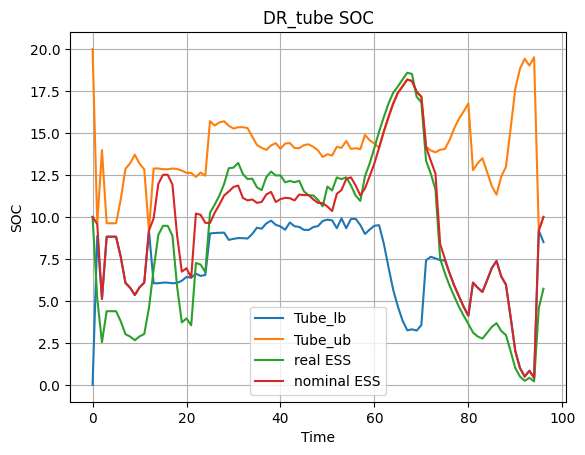

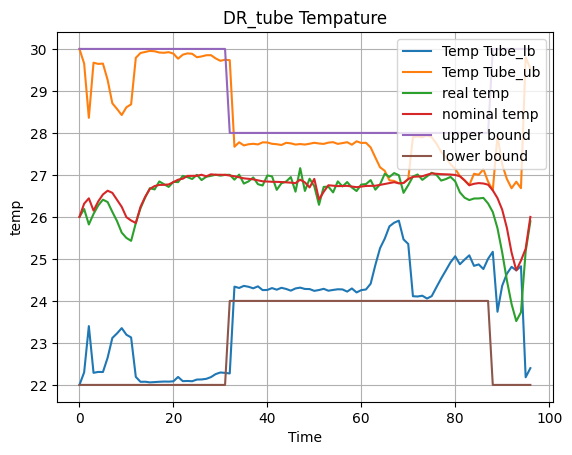

In [10]:
t_start, t_end = 0, 24 * 4 - 1
real_temp = select_data[y_temp_features].iloc[-24*4:].to_numpy()
real_pv = select_data[y_pv_features].iloc[-24*4:].to_numpy()
real_load = select_load_data[y_load_features].iloc[-24*4:].to_numpy() / 5e3
real_net_load = real_load - real_pv
ess_list = [ess_int]
nom_ess_list = [ess_int]
before_ess_list = [ess_int]
ess_tube_lb = [ess_min]
ess_tube_ub = [ess_max]
tau_list = [tau_ini]
nom_tau_list = [tau_ini]
before_tau_list = [tau_ini]
tau_tube_lb = [tau_min[t_start]]
tau_tube_ub = [tau_max[t_start]]
start_time = time.time()
cost_list = []
curr_ess = ess_int
curr_tau = tau_ini
total_penalty = 0
for curr_t in range(t_start, t_end+1):
    forecasts, controls, alphs, ther_ps, ther_taus, ess_ps, ess_esss = multi_stage_opt(curr_t, curr_ess, curr_tau, 'Uniform', 0.95)
    # Store the first control actions and their corresponding system states
    forecast_net_load, forecast_tau = forecasts 
    p_buy, p_pvc = controls
    alph_buy, alph_hvac, alph_ess, alph_pvc = alphs
    nom_p_hvac, nom_p_heat, nom_p_cool, p_heat_ub, p_cool_ub = ther_ps # corresponding to v_t
    nom_tau, tau_ub, tau_lb = ther_taus # corresponding to z_t
    nom_p_ess, nom_p_ch, nom_p_dis, nom_p_ch_ub, nom_p_dis_ub = ess_ps # corresponding to v_t
    nom_ess, ess_ub, ess_lb = ess_esss # corresponding to z_t
    elec_error = (real_net_load[curr_t] - forecast_net_load) * www
    tau_error = (real_temp[curr_t] - forecast_tau) * www
    # update system dynamics with disturbances
    curr_tau = curr_tau + gama1 * (forecast_tau - curr_tau) + gama2 * (nom_p_heat - nom_p_cool) + tau_error * gama1 + gama2 * alph_hvac * elec_error
    if elec_error <= 0:
        ess_error = elec_error / eta_dch
    else:
        ess_error = elec_error * eta_ch 
    # ess_error = -elec_error * eta_ch if elec_error < 0 else -elec_error / eta_dch
    curr_ess = curr_ess + eta_ch * nom_p_ch - nom_p_dis / eta_dch + alph_ess * ess_error
    before_ess_list.append(curr_ess)
    before_tau_list.append(curr_tau)
    # ESS correction
    if curr_ess >= ess_max:
        total_penalty += c_cur * (curr_ess - ess_max)
        curr_ess = ess_max
    elif curr_ess < ess_min:
        total_penalty += c_pen[curr_t] * (ess_min - curr_ess)
        curr_ess = ess_min
    else:
        curr_ess = curr_ess.item()
    # Temp correction
    if curr_tau >= tau_max[curr_t]:
        total_penalty += c_pen[curr_t] * (curr_tau - tau_max[curr_t]) / gama2
        curr_tau = tau_max[curr_t]
    elif curr_tau < tau_min[curr_t]:
        total_penalty += c_pen[curr_t] * (tau_min[curr_t] - curr_tau) / gama2
        curr_tau = tau_min[curr_t]
    else:
        curr_tau = curr_tau.item()
    ess_list.append(curr_ess)
    tau_list.append(curr_tau)
    nom_tau_list.append(nom_tau)
    nom_ess_list.append(nom_ess)
    # store the tube bounds
    ess_tube_lb.append(ess_lb)
    ess_tube_ub.append(ess_ub)
    tau_tube_lb.append(tau_lb)
    tau_tube_ub.append(tau_ub)
    # Update control actions based on current control actions based on linear decision rules (LDR)
    curr_p_buy = p_buy + alph_buy * elec_error
    curr_p_ch = nom_p_ch
    curr_p_dis = nom_p_dis
    curr_p_pvc = p_pvc - alph_pvc * elec_error
    # Update the current costs
    curr_C_buy = c_buy[curr_t] * curr_p_buy
    curr_C_deg = c_deg * (curr_p_ch * eta_ch + curr_p_dis / eta_dch)
    curr_C_cur = c_cur * curr_p_pvc
    curr_C_ther = c_ther * (curr_tau - tau_ref) ** 2
    cost_list.append(curr_C_buy + curr_C_deg + curr_C_cur + curr_C_ther)

end_time = time.time()
print(f"Running time: {end_time - start_time}")
print(f"Total cost: {np.sum(cost_list)+total_penalty}")
print(f"Total opration cost: {np.sum(cost_list)}")
print(f"Total penalty: {total_penalty}")
# plot the system states and control actions
# figure on ess: 
plt.plot(ess_tube_lb, label='Tube_lb')
plt.plot(ess_tube_ub, label='Tube_ub')
plt.plot(ess_list, label='real ESS')
plt.plot(nom_ess_list, label='nominal ESS')
plt.xlabel('Time')
plt.ylabel('SOC')
plt.title('DR_tube SOC')
plt.legend()
plt.grid(True)
plt.show()
# figure on temp:
plt.plot(tau_tube_lb, label='Temp Tube_lb')
plt.plot(tau_tube_ub, label='Temp Tube_ub')
plt.plot(tau_list, label='real temp')
plt.plot(nom_tau_list, label='nominal temp')
plt.plot(tau_max[:97], label='upper bound')
plt.plot(tau_min[:97], label='lower bound')
plt.xlabel('Time')
plt.ylabel('temp')
plt.title('DR_tube Tempature')
plt.legend()
plt.grid(True)
plt.show()

## DR-TMPC with introduced slack variables

In [11]:
def multi_stage_opt_slack(t0, ess0, tau0, ww, method = 'Uniform', beta = 0.95):
    """
        t0: current time
        ess0/tau0: initial states of current MPC period
        ww: hyper-parameter to control the penalty parameter for ww
    """
    # t0 should be choosen from 0-96
    tau_forecast, p_forecast, tau_scens, p_scens, weights = scen_generation(t0, method)
    Nsample, H = tau_scens.shape
    # ambiguity tube W at each time slot
    elec_W = [DR_bounds(www * p_scens[:, h], weights, beta) for h in range(H)] # an list of H arrays: [lower_bounds, upper_bounds]
    temp_W = [DR_bounds(www * tau_scens[:, h], weights, beta) for h in range(H)] # an list of H arrays: [lower_bounds, upper_bounds]
    elec_epi = np.array([radius(p_scens[:, h]) for h in range(H)])
    temp_epi = np.array([radius(tau_scens[:, h]) for h in range(H)]) # radius of temperature ambiguity is not used here
    # --- Optimization Variables Definition ----------
    # forecast error distribution factor
    alph_buy = cp.Variable(H, nonneg=True)
    alph_ess = cp.Variable(H, nonneg=True)
    alph_hvac = cp.Variable(H, nonneg=True)
    alph_pvc = cp.Variable(H, nonneg=True)
    # optimization variables of controllable units
    p_buy_hat = cp.Variable(H, nonneg=True)
    p_ess_hat = cp.Variable(H)
    p_hvac_hat = cp.Variable(H, nonneg=True)
    p_pvc_hat = cp.Variable(H, nonneg=True)
    # thermal dynamics optimization variables
    tau = cp.Variable(H) # indoor termperature
    tau_up_slack = cp.Variable(H, nonneg=True)
    tau_lo_slack = cp.Variable(H, nonneg=True)
    p_heat = cp.Variable(H, nonneg=True)
    p_cool = cp.Variable(H, nonneg=True)
    # ESS dynamics optimization variables
    ess = cp.Variable(H)
    ess_up_slack = cp.Variable(H, nonneg=True)
    ess_lo_slack = cp.Variable(H, nonneg=True)
    p_ch = cp.Variable(H, nonneg=True)
    p_dis = cp.Variable(H, nonneg=True)
    # auxiliary variables will be introduced when used
    constraints = []
    ## --- Objective Construction ---------------------
    C_deg = c_deg * (cp.sum(p_ch)*eta_ch + cp.sum(p_dis)/eta_dch)
    C_ther = c_ther * cp.norm(tau - tau_ref, 2)**2
    C_buy = c_buy[t0:t0+T_c] @ p_buy_hat
    C_cur = c_cur * cp.sum(p_pvc_hat)
    # auxiliary variables for expected objective
    cc = cp.multiply(alph_buy, c_buy[t0:t0+T_c]) - cp.multiply(alph_pvc, c_cur)
    lam_obj, s_obj = cp.Variable(H), cp.Variable((H, Nsample))
    C_exp = lam_obj @ elec_epi + cp.sum(s_obj @ weights)
    constraints.append(lam_obj >= cp.norm(cc, np.inf))
    for t in range(H):
        for i in range(Nsample):
             constraints.append(s_obj[t, i] >= cc[t] * p_scens[i, t])
    C_slack = cp.sum(ess_up_slack + ess_lo_slack + tau_up_slack + tau_lo_slack)
    obj = cp.Minimize(C_deg + C_ther + C_buy + C_cur + C_exp + ww * C_slack)
    # obj = cp.Minimize(C_deg + C_ther + C_buy + C_cur + C_exp)
    ## --- Constraints for electrical power -------------
    # chance constraints for p_t^{pv,c} non-negative
    # chance constraints for p_t^{buy} non-negative
    a_ee_cc = cp.Variable((H, 2))
    b_ee_cc = cp.Variable((H, 2))
    eta_ee_cc, s_ee_cc, lam_ee_cc = cp.Variable(H), cp.Variable((H, Nsample), nonneg=True), cp.Variable(H)
    for t in range(H):
        constraints.append(a_ee_cc[t, 0] == -alph_buy[t])
        constraints.append(a_ee_cc[t, 1] == alph_pvc[t])
        constraints.append(b_ee_cc[t, 0] == -p_buy_hat[t] - eta_ee_cc[t])
        constraints.append(b_ee_cc[t, 1] == -p_pvc_hat[t] - eta_ee_cc[t])
        constraints.append(eta_ee_cc[t] + (lam_ee_cc[t] * elec_epi[t] + weights @ s_ee_cc[t, :]) / (1-beta) <= 0)
        constraints.append(lam_ee_cc[t] >= cp.norm(a_ee_cc[t, :], np.inf))
        for i in range(Nsample):
            constraints.append(s_ee_cc[t, i] >= a_ee_cc[t, 0] * p_scens[i, t] + b_ee_cc[t, 0])
            constraints.append(s_ee_cc[t, i] >= a_ee_cc[t, 1] * p_scens[i, t] + b_ee_cc[t, 1])
    # power balance for hat variables
    constraints.append(p_forecast == p_buy_hat - p_ess_hat - p_hvac_hat - p_pvc_hat)
    # Distribution factor sum == 1
    constraints.append(alph_buy + alph_ess + alph_hvac + alph_pvc == np.ones(H))
    
    ## --- Constraints for ESS dynamics ----------------
    constraints.append(p_ess_hat == p_ch - p_dis)
    S_ess_lb, S_ess_ub = cp.Variable(H), cp.Variable(H)
    for t, WW in enumerate(elec_W):
        if t == 0:
            constraints.append(S_ess_lb[t] == alph_ess[t] * WW[0])
            constraints.append(S_ess_ub[t] == alph_ess[t] * WW[1])
        else:
            constraints.append(S_ess_lb[t] == Phi_ess * S_ess_lb[t-1] + alph_ess[t] * WW[0])
            constraints.append(S_ess_ub[t] == Phi_ess * S_ess_ub[t-1] + alph_ess[t] * WW[1])
    # constraints.append(ess_min - S_ess_lb <= ess_max - S_ess_ub)
    for t in range(H):
        # Physical constraints
        constraints.append(ess[t] <= ess_max)
        constraints.append(ess[t] >= ess_min)
        # ambiguity tube construction and slackness introduced
        constraints.append(ess[t] - ess_up_slack[t] <= ess_max - S_ess_ub[t])
        constraints.append(ess[t] + ess_lo_slack[t] >= ess_min - S_ess_lb[t]) 
        # Ambiguity Tube Construction for p_ch and p_dis
        constraints.append(p_ch[t] <= p_ch_max - K_ess[0] * S_ess_ub[t] * eta_ch)
        constraints.append(p_dis[t] <= p_dis_max + K_ess[1] * S_ess_lb[t] / eta_dch)
        # ESS System dynamics
        if t == 0:
            constraints.append(ess[t] == ess0 + eta_ch * p_ch[t] - p_dis[t] / eta_dch)
        else:
            constraints.append(ess[t] == ess[t-1] + eta_ch * p_ch[t] - p_dis[t] / eta_dch)
        if t + t0 == 95: # ensure that the SOC at the beginning and in the end are the same 
            # constraints.append(ess_end_slack == ess[t] - ess_int)
            constraints.append(ess[t] == ess_int)

    ## --- Constraints for thermal dynamics ---------------
    constraints.append(p_hvac_hat == p_heat + p_cool)
    S_temp_lb, S_temp_ub = cp.Variable(H), cp.Variable(H)
    # constraints.append(tau_min[t0:t0+H] - S_temp_lb <= tau_max[t0:t0+H] - S_temp_ub)
    for t, WW in enumerate(temp_W):
        EE = elec_W[t]
        # The time-coupled ambiguity tube construction
        if t == 0:
            constraints.append(S_temp_lb[t] == 1 * gama1 * WW[0] + gama2 * EE[0] * alph_hvac[t])
            constraints.append(S_temp_ub[t] == 1 * gama1 * WW[1] + gama2 * EE[1] * alph_hvac[t])
        else:
            constraints.append(S_temp_lb[t] == Phi_temp * S_temp_lb[t-1] + 1 * gama1 * WW[0] + gama2 * EE[0] * alph_hvac[t])
            constraints.append(S_temp_ub[t] == Phi_temp * S_temp_ub[t-1] + 1 * gama1 * WW[1] + gama2 * EE[1] * alph_hvac[t])
    for t in range(H):
        # Physical constraints
        constraints.append(tau[t] <= tau_max[t0+t])
        constraints.append(tau[t] >= tau_min[t0+t])
        # Ambiguity tube construction and slackness introduced
        constraints.append(tau[t] - tau_up_slack[t] <= tau_max[t0+t] - S_temp_ub[t])
        constraints.append(tau[t] + tau_lo_slack[t] >= tau_min[t0+t] - S_temp_lb[t])
        # Ambiguity Tube Construction for p_cool and p_heat
        constraints.append(p_heat[t] <= p_hvac_max - K_temp[0] * S_temp_ub[t]) 
        constraints.append(p_cool[t] <= p_hvac_max + K_temp[1] * S_temp_lb[t])
        # Thermal Dynamics
        if t == 0:
            constraints.append(tau[t] == (1-gama1) * tau0 + gama2 * (p_heat[t] - p_cool[t]) + gama1 * tau_forecast[t])
        else:
            constraints.append(tau[t] == (1-gama1) * tau[t-1] + gama2 * (p_heat[t] - p_cool[t]) + gama1 * tau_forecast[t])
        if t + t0 == 95:
            constraints.append(tau[t] == tau_ini)
            # constraints.append(tau_end_slack == tau[t] - tau_ini)
    # constraints.append(alph_hvac <= 0)
    # constraints.append(alph_ess <= 0)
    # constraints.append(alph_pvc >= 0.1)
    # constraints.append(alph_buy >= 0.1)
    ## --- Problem solvement -------------------------------
    problem = cp.Problem(obj, constraints)
    problem.solve(solver=cp.GUROBI)
    time3 = time.time()
    # print(f"Optimization Time: {time3 - time2}")
    print(f"Current Iteration: {t0} Problem status: {problem.status}")
    if problem.status != 'optimal':
        print(elec_W)
        print(temp_W)
    forecasts = [p_forecast[0], tau_forecast[0]]
    controls = [p_buy_hat.value[0], p_pvc_hat.value[0]]
    alphs = [alph_buy.value[0], alph_hvac.value[0], alph_ess.value[0], alph_pvc.value[0]]
    ther_ps = [p_hvac_hat.value[0], p_heat.value[0], p_cool.value[0], p_hvac_max - K_temp[0] * S_temp_ub.value[0], p_hvac_max + K_temp[1] * S_temp_lb.value[0]]
    ther_taus = [tau.value[0], tau_max[t0] - S_temp_ub.value[0], tau_min[t0] - S_temp_lb.value[0]]
    ess_ps = [p_ess_hat.value[0], p_ch.value[0], p_dis.value[0], p_ch_max - K_ess[0] * S_ess_ub.value[0], p_dis_max + K_ess[1] * S_ess_lb.value[0]]
    ess_esss = [ess.value[0], ess_max - S_ess_ub.value[0], ess_min - S_ess_lb.value[0]]
    return forecasts, controls, alphs, ther_ps, ther_taus, ess_ps, ess_esss


In [ ]:
print(np.max(c_buy))

1.5024775377150517


1
Current Iteration: 0 Problem status: optimal
Current Iteration: 1 Problem status: optimal
Current Iteration: 2 Problem status: optimal
Current Iteration: 3 Problem status: optimal
Current Iteration: 4 Problem status: optimal
Current Iteration: 5 Problem status: optimal
Current Iteration: 6 Problem status: optimal
Current Iteration: 7 Problem status: optimal
Current Iteration: 8 Problem status: optimal
Current Iteration: 9 Problem status: optimal
Current Iteration: 10 Problem status: optimal
Current Iteration: 11 Problem status: optimal
Current Iteration: 12 Problem status: optimal
Current Iteration: 13 Problem status: optimal
Current Iteration: 14 Problem status: optimal
Current Iteration: 15 Problem status: optimal
Current Iteration: 16 Problem status: optimal
Current Iteration: 17 Problem status: optimal
Current Iteration: 18 Problem status: optimal
Current Iteration: 19 Problem status: optimal
Current Iteration: 20 Problem status: optimal
Current Iteration: 21 Problem status: opti

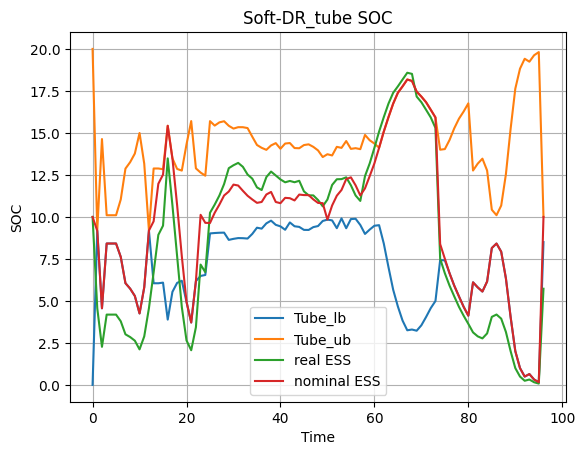

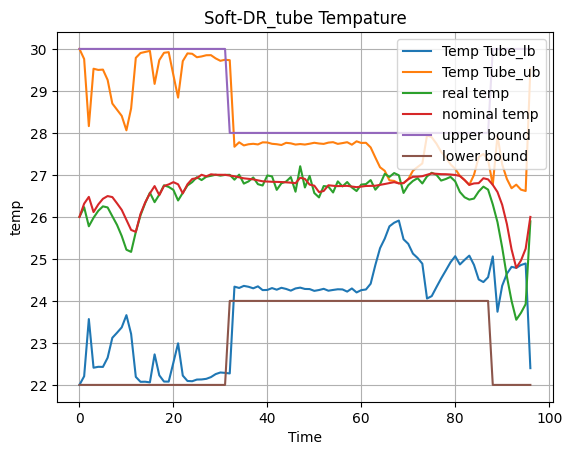

In [12]:
t_start, t_end = 0, 24 * 4 - 1
real_temp = select_data[y_temp_features].iloc[-24*4:].to_numpy()
real_pv = select_data[y_pv_features].iloc[-24*4:].to_numpy()
real_load = select_load_data[y_load_features].iloc[-24*4:].to_numpy() / 5e3
real_net_load = real_load - real_pv
ess_list = [ess_int]
nom_ess_list = [ess_int]
ess_tube_lb = [ess_min]
ess_tube_ub = [ess_max]
tau_list = [tau_ini]
nom_tau_list = [tau_ini]
tau_tube_lb = [tau_min[t_start]]
tau_tube_ub = [tau_max[t_start]]
before_ess_list = [ess_int]
before_tau_list = [tau_ini]
start_time = time.time()
cost_list = []
curr_ess = ess_int
curr_tau = tau_ini
total_penalty = 0
# ww = np.max(c_buy)
# ww = 2.5
ww = 1
print(ww)
for curr_t in range(t_start, t_end+1):
    forecasts, controls, alphs, ther_ps, ther_taus, ess_ps, ess_esss = multi_stage_opt_slack(curr_t, curr_ess, curr_tau, ww, 'Uniform', 0.95)
    # Store the first control actions and their corresponding system states
    forecast_net_load, forecast_tau = forecasts 
    p_buy, p_pvc = controls
    alph_buy, alph_hvac, alph_ess, alph_pvc = alphs
    nom_p_hvac, nom_p_heat, nom_p_cool, p_heat_ub, p_cool_ub = ther_ps # corresponding to v_t
    nom_tau, tau_ub, tau_lb = ther_taus # corresponding to z_t
    nom_p_ess, nom_p_ch, nom_p_dis, nom_p_ch_ub, nom_p_dis_ub = ess_ps # corresponding to v_t
    nom_ess, ess_ub, ess_lb = ess_esss # corresponding to z_t
    elec_error = (real_net_load[curr_t] - forecast_net_load) * www
    tau_error = (real_temp[curr_t] - forecast_tau) * www
    # update system dynamics with disturbances
    curr_tau = curr_tau + gama1 * (forecast_tau - curr_tau) + gama2 * (nom_p_heat - nom_p_cool) + tau_error * gama1 + gama2 * alph_hvac * elec_error
    if elec_error <= 0: 
        ess_error = elec_error / eta_dch
    else:
        ess_error = elec_error * eta_ch 
    # ess_error = -elec_error * eta_ch if elec_error < 0 else -elec_error / eta_dch
    curr_ess = curr_ess + eta_ch * nom_p_ch - nom_p_dis / eta_dch + alph_ess * ess_error
    before_tau_list.append(curr_tau)
    before_ess_list.append(curr_ess)
    # ESS correction
    if curr_ess >= ess_max:
        total_penalty += c_cur * (curr_ess - ess_max)
        curr_ess = ess_max
    elif curr_ess < ess_min:
        total_penalty += c_pen[curr_t] * (ess_min - curr_ess)
        curr_ess = ess_min
    else:
        curr_ess = curr_ess.item()
    # Temp correction
    if curr_tau >= tau_max[curr_t]:
        total_penalty += c_pen[curr_t] * (curr_tau - tau_max[curr_t]) / gama2
        curr_tau = tau_max[curr_t]
    elif curr_tau < tau_min[curr_t]:
        total_penalty += c_pen[curr_t] * (tau_min[curr_t] - curr_tau) / gama2
        curr_tau = tau_min[curr_t]
    else:
        curr_tau = curr_tau.item()
    ess_list.append(curr_ess)
    tau_list.append(curr_tau)
    nom_tau_list.append(nom_tau)
    nom_ess_list.append(nom_ess)
    # store the tube bounds
    ess_tube_lb.append(ess_lb)
    ess_tube_ub.append(ess_ub)
    tau_tube_lb.append(tau_lb)
    tau_tube_ub.append(tau_ub)
    # Update control actions based on current control actions based on linear decision rules (LDR)
    curr_p_buy = p_buy + alph_buy * elec_error
    curr_p_ch = nom_p_ch
    curr_p_dis = nom_p_dis
    curr_p_pvc = p_pvc - alph_pvc * elec_error
    # Update the current costs
    curr_C_buy = c_buy[curr_t] * curr_p_buy
    curr_C_deg = c_deg * (curr_p_ch * eta_ch + curr_p_dis / eta_dch)
    curr_C_cur = c_cur * curr_p_pvc
    curr_C_ther = c_ther * (curr_tau - tau_ref) ** 2
    cost_list.append(curr_C_buy + curr_C_deg + curr_C_cur + curr_C_ther)

end_time = time.time()
print(f"Running time: {end_time - start_time}")
print(f"Total cost: {np.sum(cost_list)+total_penalty}")
print(f"Total opration cost: {np.sum(cost_list)}")
print(f"Total penalty: {total_penalty}")
# plot the system states and control actions
# figure on ess: 
plt.plot(ess_tube_lb, label='Tube_lb')
plt.plot(ess_tube_ub, label='Tube_ub')
plt.plot(ess_list, label='real ESS')
plt.plot(nom_ess_list, label='nominal ESS')
plt.xlabel('Time')
plt.ylabel('SOC')
plt.title('Soft-DR_tube SOC')
plt.legend()
plt.grid(True)
plt.show()
# figure on temp:
plt.plot(tau_tube_lb, label='Temp Tube_lb')
plt.plot(tau_tube_ub, label='Temp Tube_ub')
plt.plot(tau_list, label='real temp')
plt.plot(nom_tau_list, label='nominal temp')
plt.plot(tau_max[:97], label='upper bound')
plt.plot(tau_min[:97], label='lower bound')
plt.xlabel('Time')
plt.ylabel('temp')
plt.title('Soft-DR_tube Tempature')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
def extract_scalar(x):
    if isinstance(x, np.ndarray):
        # Use .item() to extract the single value from a 0-dim or 1x1 array
        return x.item()
    else:
        # If it's already a float or something else, return it as is
        return x

In [ ]:
data_dict = {
    'ESS Upper Bound': [ess_max for i in range(97)],
    'ESS Lower Bound': [ess_min for i in range(97)],
    'ESS Upper Tube': ess_tube_ub,
    'ESS Lower Tube': ess_tube_lb,
    'ESS nominal': nom_ess_list,
    'ESS actual': ess_list,
    'ESS before': before_ess_list,
    'Temp Upper Bound': tau_max[:97],
    'Temp Lower Bound': tau_min[:97],
    'Temp Upper Tube': tau_tube_ub,
    'Temp Lower Tube': tau_tube_lb,
    'Temp nominal': nom_tau_list,
    'Temp actual': tau_list,
    'Temp before': before_tau_list,
}
df = pd.DataFrame(data_dict)
cols_to_clean = ['ESS before', 'Temp before']
for col in cols_to_clean:
    df[col] = df[col].apply(extract_scalar)
# df.to_csv(f"numerical results/0706soft_DRTMPC.csv", index=False)

## Standard MPC with predictions

In [14]:
# This function is standard MPC
def mpc(t0, ess0, tau0):
    # t0 should be choosen from 0-23
    tau_forecast, p_forecast, _, _, _ = scen_generation(t0)
    H = tau_forecast.shape[0]
    # Optimization variables setup
    p_buy_hat = cp.Variable(H, nonneg=True)
    p_pvc_hat = cp.Variable(H, nonneg=True)
    p_ch_hat = cp.Variable(H, nonneg=True)
    p_dis_hat = cp.Variable(H, nonneg=True)
    p_ess_hat = cp.Variable(H)
    p_hvac_hat = cp.Variable(H)
    p_heat_hat = cp.Variable(H, nonneg=True)
    p_cool_hat = cp.Variable(H, nonneg=True)
    tau_hat = cp.Variable(H)
    ess_hat = cp.Variable(H)
    # Objective Setup
    C_buy = c_buy[t0:t0+T_c] @ p_buy_hat
    C_deg = c_deg * (eta_ch * cp.sum(p_ch_hat) + cp.sum(p_dis_hat) / eta_dch)
    C_cur = c_cur * cp.sum(p_pvc_hat)
    C_ther = c_ther * cp.norm(tau_hat - tau_ref, 2) ** 2
    obj = cp.Minimize(C_buy + C_deg + C_cur + C_ther)
    constraints = []
    # Constraints Setup
    # ESS dynamics
    for t in range(H):
        if t == 0:
            constraints.append(ess_hat[t] == ess0 + eta_ch * p_ch_hat[t] - p_dis_hat[t] / eta_dch)
        else:
            constraints.append(ess_hat[t] == ess_hat[t-1] + eta_ch * p_ch_hat[t] - p_dis_hat[t] / eta_dch)
        if t + t0 == 24 * 4 - 1:
            constraints.append(ess_hat[t] == ess_int)
    constraints.append(ess_hat <= ess_max)
    constraints.append(ess_hat >= ess_min)
    constraints.append(p_ch_hat <= p_ch_max)
    constraints.append(p_dis_hat <= p_dis_max)
    constraints.append(p_ess_hat == p_ch_hat - p_dis_hat)
    # Thermal Dynamics
    for t in range(H):
        if t == 0:
            constraints.append(tau_hat[t] == tau0 + gama1 * (tau_forecast[t] - tau0) + gama2 * (p_heat_hat[t] - p_cool_hat[t]))
        else:
            constraints.append(tau_hat[t] == tau_hat[t-1] + gama1 * (tau_forecast[t] - tau_hat[t-1]) + gama2 * (p_heat_hat[t] - p_cool_hat[t]))
        if t + t0 == 24 * 4 - 1:
            constraints.append(tau_hat[t] == tau_ini)
    constraints.append(tau_hat <= tau_max[t0:t0+H])
    constraints.append(tau_hat >= tau_min[t0:t0+H])
    constraints.append(p_heat_hat <= p_hvac_max)
    constraints.append(p_cool_hat <= p_hvac_max)
    constraints.append(p_hvac_hat == p_heat_hat + p_cool_hat) 
    # power balance
    constraints.append(p_forecast + p_ess_hat + p_hvac_hat + p_pvc_hat == p_buy_hat)
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.GUROBI)
    print(f"Current time: {curr_t}. Problem Status: {prob.status}")
    forecasts = [p_forecast[0], tau_forecast[0]]
    controls = [p_buy_hat.value[0], p_pvc_hat.value[0]]
    ther_ps = [p_hvac_hat.value[0], p_heat_hat.value[0], p_cool_hat.value[0]]
    ther_taus = [tau_hat.value[0]]
    ess_ps = [p_ess_hat.value[0], p_ch_hat.value[0], p_dis_hat.value[0]]
    ess_esss = [ess_hat.value[0]]
    return forecasts, controls, ther_ps, ther_taus, ess_ps, ess_esss

Current time: 0. Problem Status: optimal
Current time: 1. Problem Status: optimal
Current time: 2. Problem Status: optimal
Current time: 3. Problem Status: optimal
Current time: 4. Problem Status: optimal
Current time: 5. Problem Status: optimal
Current time: 6. Problem Status: optimal
Current time: 7. Problem Status: optimal
Current time: 8. Problem Status: optimal
Current time: 9. Problem Status: optimal
Current time: 10. Problem Status: optimal
Current time: 11. Problem Status: optimal
Current time: 12. Problem Status: optimal
Current time: 13. Problem Status: optimal
Current time: 14. Problem Status: optimal
Current time: 15. Problem Status: optimal
Current time: 16. Problem Status: optimal
Current time: 17. Problem Status: optimal
Current time: 18. Problem Status: optimal
Current time: 19. Problem Status: optimal
Current time: 20. Problem Status: optimal
Current time: 21. Problem Status: optimal
Current time: 22. Problem Status: optimal
Current time: 23. Problem Status: optimal
Cu

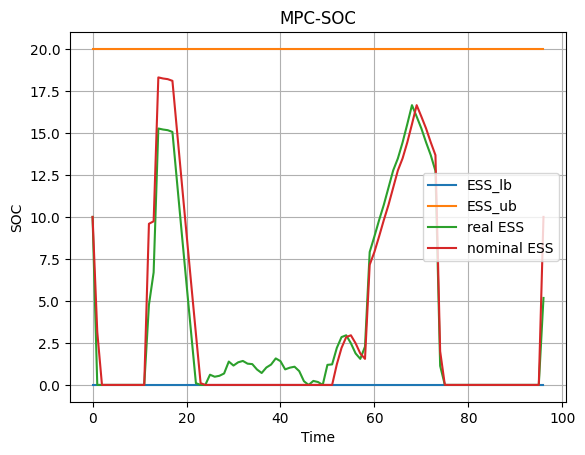

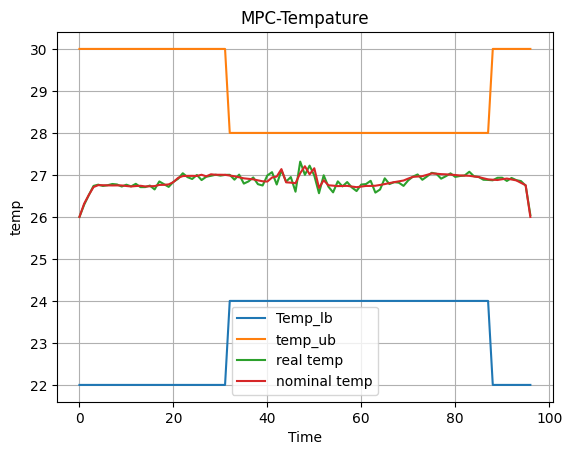

In [15]:
t_start, t_end = 0, 4 * 24 - 1
real_temp = select_data[y_temp_features].iloc[-24*4:].to_numpy()
real_pv = select_data[y_pv_features].iloc[-24*4:].to_numpy()
real_load = select_load_data[y_load_features].iloc[-24*4:].to_numpy() / 5e3
real_net_load = real_load - real_pv
ess_list = [ess_int]
nom_ess_list = [ess_int]
tau_list = [tau_ini]
nom_tau_list = [tau_ini]
before_tau_list = [tau_ini]
before_ess_list = [ess_int]
start_time = time.time()
cost_list = []
curr_ess = ess_int
curr_tau = tau_ini
total_penalty = 0
for curr_t in range(t_start, t_end+1):
    forecasts, controls, ther_ps, ther_taus, ess_ps, ess_esss = mpc(curr_t, curr_ess, curr_tau)
    forecast_net_load, forecast_tau = forecasts
    p_buy, p_pvc = controls
    p_hvac, p_heat, p_cool = ther_ps
    tau = ther_taus[0]
    p_ess, p_ch, p_dis = ess_ps
    ess = ess_esss[0]
    elec_error = (real_net_load[curr_t] - forecast_net_load) * www
    tau_error = (real_temp[curr_t] - forecast_tau) * www
    # Update system disturbance according to the disturbances
    curr_tau = curr_tau + gama1 * (forecast_tau - curr_tau) + gama2 * (p_heat - p_cool) + tau_error * gama1
    curr_ess = curr_ess + eta_ch * p_ch - p_dis / eta_dch 

    if elec_error <= 0:
        curr_ess += elec_error / eta_dch
    else:
        curr_ess += elec_error * eta_ch 
    before_ess_list.append(curr_ess)
    before_tau_list.append(curr_tau)
    # ESS correction
    if curr_ess >= ess_max:
        total_penalty += c_cur * (curr_ess - ess_max)
        curr_ess = ess_max
    elif curr_ess < ess_min:
        total_penalty += c_pen[curr_t] * (ess_min - curr_ess)
        curr_ess = ess_min
    else:
        curr_ess = curr_ess.item()
    # Temp correction
    if curr_tau >= tau_max[curr_t]:
        total_penalty += c_pen[curr_t] * (curr_tau - tau_max[curr_t]) / gama2
        curr_tau = tau_max[curr_t]
    elif curr_tau < tau_min[curr_t]:
        total_penalty += c_pen[curr_t] * (tau_min[curr_t] - curr_tau) / gama2
        curr_tau = tau_min[curr_t]
    else:
        curr_tau = curr_tau.item()


    ess_list.append(curr_ess)
    tau_list.append(curr_tau)
    nom_ess_list.append(ess)
    nom_tau_list.append(tau)
    # Update the current costs
    curr_C_buy = c_buy[curr_t] * p_buy
    curr_C_deg = c_deg * (p_ch * eta_ch + p_dis / eta_dch)
    curr_C_cur = c_cur * p_pvc
    curr_C_ther = c_ther * (curr_tau - tau_ref) ** 2
    cost_list.append(curr_C_buy + curr_C_deg + curr_C_cur + curr_C_ther)

end_time = time.time()
print(f"Running Time: {end_time - start_time}")
print(f"Total Cost: {np.sum(cost_list) + total_penalty}")
print(f"Total operational cost: {np.sum(cost_list)}")
print(f"Total penalty: {total_penalty}")
# plot the system states and control actions
# figure on ess: 
plt.plot([ess_min for _ in range(len(ess_list))], label='ESS_lb')
plt.plot([ess_max for _ in range(len(ess_list))], label='ESS_ub')
plt.plot(ess_list, label='real ESS')
plt.plot(nom_ess_list, label='nominal ESS')
plt.xlabel('Time')
plt.ylabel('SOC')
plt.title('MPC-SOC')
plt.legend()
plt.grid(True)
plt.show()
# figure on temp:
# plt.plot([tau_min for _ in range(len(ess_list))], label='Temp lb')
# plt.plot([tau_max for _ in range(len(ess_list))], label='Temp ub')
plt.plot(tau_min[:len(tau_list)], label='Temp_lb')
plt.plot(tau_max[:len(tau_list)], label='temp_ub')
plt.plot(tau_list, label='real temp')
plt.plot(nom_tau_list, label='nominal temp')
plt.xlabel('Time')
plt.ylabel('temp')
plt.title('MPC-Tempature')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
data_dict = {
    'ESS Upper Bound': [ess_max for i in range(97)],
    'ESS Lower Bound': [ess_min for i in range(97)],
    'ESS nominal': nom_ess_list,
    'ESS actual': ess_list,
    'ESS before': before_ess_list,
    'Temp Upper Bound': tau_max[:97],
    'Temp Lower Bound': tau_min[:97],
    'Temp nominal': nom_tau_list,
    'Temp actual': tau_list,
    'Temp before': before_tau_list,
}
df = pd.DataFrame(data_dict)
cols_to_clean = ['ESS before', 'Temp before']
for col in cols_to_clean:
    df[col] = df[col].apply(extract_scalar)
df


,ESS Upper Bound,ESS Lower Bound,ESS nominal,ESS actual,ESS before,Temp Upper Bound,Temp Lower Bound,Temp nominal,Temp actual,Temp before
0,20,0,1.000000e+01,10.000000,10.000000,30.0,22.0,26.000000,26.000000,26.000000
1,20,0,3.153330e+00,0.000000,-1.669321,30.0,22.0,26.315952,26.290000,26.290000
2,20,0,3.244055e-07,0.000000,-4.822651,30.0,22.0,26.523775,26.522000,26.522000
3,20,0,2.117644e-06,0.000000,-4.822649,30.0,22.0,26.711285,26.738910,26.738910
4,20,0,2.895893e-07,0.000000,-4.822651,30.0,22.0,26.756480,26.767860,26.767860
...,...,...,...,...,...,...,...,...,...,...
92,20,0,3.315022e-08,0.000000,-4.822651,30.0,22.0,26.891518,26.927406,26.927406
93,20,0,9.942296e-06,0.000000,-4.822641,30.0,22.0,26.869933,26.875815,26.875815
94,20,0,1.438442e-06,0.000000,-4.822649,30.0,22.0,26.811734,26.853186,26.853186
95,20,0,9.358393e-06,0.000000,-4.822642,30.0,22.0,26.754990,26.744835,26.744835


## MPC with perfect prediction

In [16]:
def mpc_perfect_pred(t0, ess0, tau0):
    H = T_c
    # cannot use 
    tau_forecast, p_forecast = real_temp[t0:t0+H].reshape(-1), real_net_load[t0:t0+H].reshape(-1)
    time1 = time.time()
    # Optimization variables setup
    p_buy_hat = cp.Variable(H, nonneg=True)
    p_pvc_hat = cp.Variable(H, nonneg=True)
    p_ch_hat = cp.Variable(H, nonneg=True)
    p_dis_hat = cp.Variable(H, nonneg=True)
    p_ess_hat = cp.Variable(H)
    p_hvac_hat = cp.Variable(H)
    p_heat_hat = cp.Variable(H, nonneg=True)
    p_cool_hat = cp.Variable(H, nonneg=True)
    tau_hat = cp.Variable(H)
    ess_hat = cp.Variable(H)
    # Objective Setup
    C_buy = c_buy[t0:t0+H] @ p_buy_hat
    C_deg = c_deg * (eta_ch * cp.sum(p_ch_hat) + cp.sum(p_dis_hat) / eta_dch)
    C_cur = c_cur * cp.sum(p_pvc_hat)
    C_ther = c_ther * cp.norm(tau_hat - tau_ref, 2) ** 2
    obj = cp.Minimize(C_buy + C_deg + C_cur + C_ther)
    constraints = []
    # Constraints Setup
    # ESS dynamics
    for t in range(H):
        if t == 0:
            constraints.append(ess_hat[t] == ess0 + eta_ch * p_ch_hat[t] - p_dis_hat[t] / eta_dch)
        else:
            constraints.append(ess_hat[t] == ess_hat[t-1] + eta_ch * p_ch_hat[t] - p_dis_hat[t] / eta_dch)
        if t + t0 == 4 * 24 - 1:
            constraints.append(ess_hat[t] == ess_int)
    constraints.append(ess_hat <= ess_max)
    constraints.append(ess_hat >= ess_min)
    constraints.append(p_ch_hat <= p_ch_max)
    constraints.append(p_dis_hat <= p_dis_max)
    constraints.append(p_ess_hat == p_ch_hat - p_dis_hat)
    # Thermal Dynamics
    for t in range(H):
        if t == 0:
            constraints.append(tau_hat[t] == tau0 + gama1 * (tau_forecast[t] - tau0) + gama2 * (p_heat_hat[t] - p_cool_hat[t]))
        else:
            constraints.append(tau_hat[t] == tau_hat[t-1] + gama1 * (tau_forecast[t] - tau_hat[t-1]) + gama2 * (p_heat_hat[t] - p_cool_hat[t]))
        if t + t0 == 4 * 24 - 1:
            constraints.append(tau_hat[t] == tau_ini)
    constraints.append(tau_hat <= tau_max[t0+t])
    constraints.append(tau_hat >= tau_min[t0+t])
    constraints.append(p_heat_hat <= p_hvac_max)
    constraints.append(p_cool_hat <= p_hvac_max)
    constraints.append(p_hvac_hat == p_heat_hat + p_cool_hat) 
    # power balance
    constraints.append(p_forecast + p_ess_hat + p_hvac_hat + p_pvc_hat == p_buy_hat)
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.GUROBI)
    print(f"Current time: {curr_t}. Problem Status: {prob.status}")
    forecasts = [p_forecast[0], tau_forecast[0]]
    controls = [p_buy_hat.value[0], p_pvc_hat.value[0]]
    ther_ps = [p_hvac_hat.value[0], p_heat_hat.value[0], p_cool_hat.value[0]]
    ther_taus = [tau_hat.value[0]]
    ess_ps = [p_ess_hat.value[0], p_ch_hat.value[0], p_dis_hat.value[0]]
    ess_esss = [ess_hat.value[0]]
    return forecasts, controls, ther_ps, ther_taus, ess_ps, ess_esss

Current time: 0. Problem Status: optimal
Current time: 1. Problem Status: optimal
Current time: 2. Problem Status: optimal
Current time: 3. Problem Status: optimal
Current time: 4. Problem Status: optimal
Current time: 5. Problem Status: optimal
Current time: 6. Problem Status: optimal
Current time: 7. Problem Status: optimal
Current time: 8. Problem Status: optimal
Current time: 9. Problem Status: optimal
Current time: 10. Problem Status: optimal
Current time: 11. Problem Status: optimal
Current time: 12. Problem Status: optimal
Current time: 13. Problem Status: optimal
Current time: 14. Problem Status: optimal
Current time: 15. Problem Status: optimal
Current time: 16. Problem Status: optimal
Current time: 17. Problem Status: optimal
Current time: 18. Problem Status: optimal
Current time: 19. Problem Status: optimal
Current time: 20. Problem Status: optimal
Current time: 21. Problem Status: optimal
Current time: 22. Problem Status: optimal
Current time: 23. Problem Status: optimal
Cu

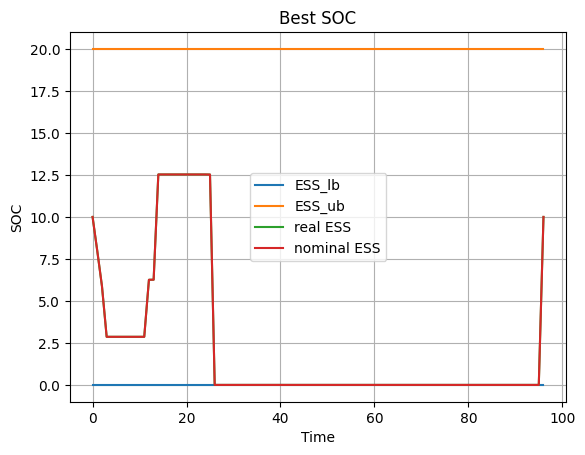

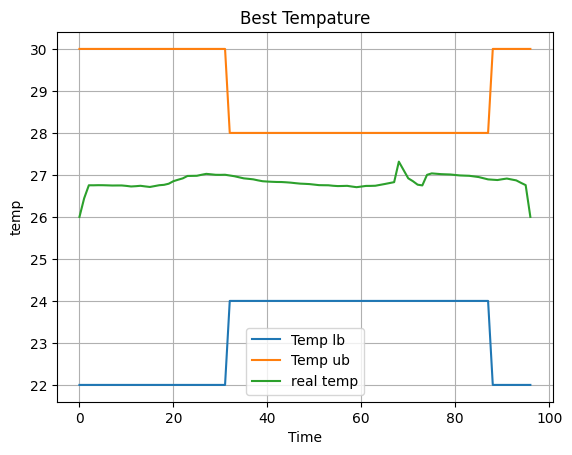

In [17]:
t_start, t_end = 0, 24 * 4 - 1
candidate_index_start = (cum_before[candidate_month-1] + candidate_day-2) * 24 * 4
candidate_index_end = candidate_index_start + 48 * 4 + 4 * 4
mask = (data['month'] == candidate_month) & (data['day'].isin([candidate_day, candidate_day-1]))
select2_data = data.loc[mask]
select2_load_data = load_data.iloc[candidate_index_start:candidate_index_end, :]
real_temp = select2_data[y_temp_features].iloc[-24*4-4*4:].to_numpy()
real_pv = select2_data[y_pv_features].iloc[-24*4-4*4:].to_numpy()
real_load = select2_load_data[y_load_features].iloc[-24*4-4*4:].to_numpy() / 5e3
real_net_load = real_load - real_pv
ess_list = [ess_int]
nom_ess_list = [ess_int]
tau_list = [tau_ini]
nom_tau_list = [tau_ini]
before_tau_list = [tau_ini]
before_ess_list = [ess_int]
start_time = time.time()
cost_list = []
curr_ess = ess_int
curr_tau = tau_ini
total_penalty = 0
for curr_t in range(t_start, t_end+1):
    forecasts, controls, ther_ps, ther_taus, ess_ps, ess_esss = mpc_perfect_pred(curr_t, curr_ess, curr_tau)
    forecast_net_load, forecast_tau = forecasts
    p_buy, p_pvc = controls
    p_hvac, p_heat, p_cool = ther_ps
    tau = ther_taus[0]
    p_ess, p_ch, p_dis = ess_ps
    ess = ess_esss[0]
    elec_error = (real_net_load[curr_t] - forecast_net_load) * www
    tau_error = (real_temp[curr_t] - forecast_tau) * www
    # Update system disturbance according to the disturbances
    curr_tau = curr_tau + gama1 * (forecast_tau - curr_tau) + gama2 * (p_heat - p_cool) + tau_error * gama1
    curr_ess = curr_ess + eta_ch * p_ch - p_dis / eta_dch

    if elec_error >= 0:
        total_penalty += c_buy[curr_t] * elec_error
    else:
        total_penalty += - c_cur * elec_error
    # ESS correction
    if curr_ess >= ess_max:
        total_penalty += c_cur * (curr_ess - ess_max)
        curr_ess = ess_max
    elif curr_ess < ess_min:
        total_penalty += c_pen[curr_t] * (ess_min - curr_ess)
        curr_ess = ess_min
    else:
        curr_ess = curr_ess.item()
    # Temp correction
    if curr_tau >= tau_max[curr_t]:
        total_penalty += c_pen[curr_t] * (curr_tau - tau_max[curr_t]) / gama2
        curr_tau = tau_max[curr_t]
    elif curr_tau < tau_min[curr_t]:
        total_penalty += c_pen[curr_t] * (tau_min[curr_t] - curr_tau) / gama2
        curr_tau = tau_min
    else:
        curr_tau = curr_tau.item()


    ess_list.append(curr_ess)
    tau_list.append(curr_tau)
    nom_ess_list.append(ess)
    nom_tau_list.append(tau)
    # Update the current costs
    curr_C_buy = c_buy[curr_t] * p_buy
    curr_C_deg = c_deg * (p_ch * eta_ch + p_dis / eta_dch)
    curr_C_cur = c_cur * p_pvc
    curr_C_ther = c_ther * (curr_tau - tau_ref) ** 2
    cost_list.append(curr_C_buy + curr_C_deg + curr_C_cur + curr_C_ther)

end_time = time.time()
print(f"Running Time: {end_time - start_time}")
print(f"Total Cost: {np.sum(cost_list) + total_penalty}")
print(f"Total operational cost: {np.sum(cost_list)}")
print(f"Total penalty: {total_penalty}")
# plot the system states and control actions
# figure on ess: 
plt.plot([ess_min for _ in range(len(ess_list))], label='ESS_lb')
plt.plot([ess_max for _ in range(len(ess_list))], label='ESS_ub')
plt.plot(ess_list, label='real ESS')
plt.plot(nom_ess_list, label='nominal ESS')
plt.xlabel('Time')
plt.ylabel('SOC')
plt.title('Best SOC')
plt.legend()
plt.grid(True)
plt.show()
# figure on temp:
# plt.plot([tau_min for _ in range(len(ess_list))], label='Temp lb')
plt.plot(tau_min[:len(tau_list)], label='Temp lb')
plt.plot(tau_max[:len(tau_list)], label='Temp ub')
# plt.plot([tau_max for _ in range(len(ess_list))], label='Temp ub')
plt.plot(tau_list, label='real temp')
# plt.plot(nom_tau_list, label='nominal temp')
plt.xlabel('Time')
plt.ylabel('temp')
plt.title('Best Tempature')
plt.legend()
plt.grid(True)
plt.show()

## Scenario-based MPC

Current time: 0, problem status: optimal
Current time: 1, problem status: optimal
Current time: 2, problem status: optimal
Current time: 3, problem status: optimal
Current time: 4, problem status: optimal
Current time: 5, problem status: optimal
Current time: 6, problem status: optimal
Current time: 7, problem status: optimal
Current time: 8, problem status: optimal
Current time: 9, problem status: optimal
Current time: 10, problem status: optimal
Current time: 11, problem status: optimal
Current time: 12, problem status: optimal
Current time: 13, problem status: optimal
Current time: 14, problem status: optimal
Current time: 15, problem status: optimal
Current time: 16, problem status: optimal
Current time: 17, problem status: optimal
Current time: 18, problem status: optimal
Current time: 19, problem status: optimal
Current time: 20, problem status: optimal
Current time: 21, problem status: optimal
Current time: 22, problem status: optimal
Current time: 23, problem status: optimal
Cu

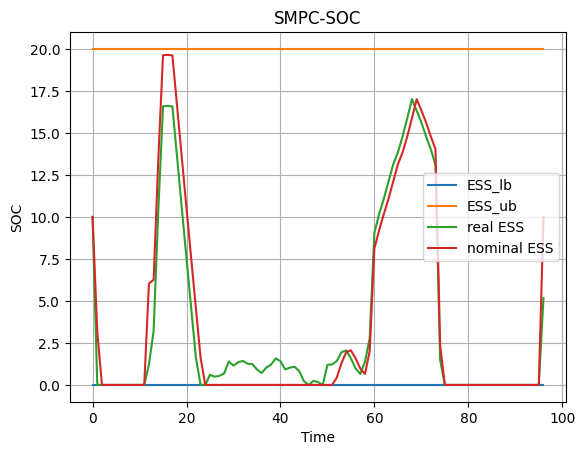

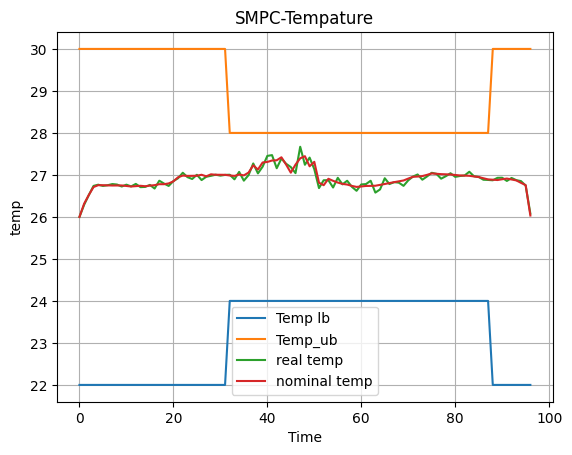

In [18]:
def scenario_mpc(t0, ess0, tau0, method='Uniform'):
    tau_forecast, p_forecast, tau_scens, p_scens, weights = scen_generation(t0, method)
    
    tau_scens = tau_scens + tau_forecast
    p_scens = www * p_scens + p_forecast
    # print(tau_scens.shape)
    # print(p_scens.shape)
    time1 = time.time()
    Nsample, H = tau_scens.shape
    # optimization variables construction
    p_buy = cp.Variable((Nsample, H), nonneg=True)
    p_pvc = cp.Variable((Nsample, H), nonneg=True)
    p_ch = cp.Variable((Nsample, H), nonneg=True)
    p_dis = cp.Variable((Nsample, H), nonneg=True)
    p_ess = cp.Variable((Nsample, H))
    ess = cp.Variable((Nsample, H))
    p_heat = cp.Variable((Nsample, H), nonneg=True)
    p_cool = cp.Variable((Nsample, H), nonneg=True)
    p_hvac = cp.Variable((Nsample, H))
    tau = cp.Variable((Nsample, H))
    # Keep the first time period as the same
    p_buy_hat = cp.Variable(nonneg=True)
    p_pvc_hat = cp.Variable(nonneg=True)
    p_ch_hat = cp.Variable(nonneg=True)
    p_dis_hat = cp.Variable(nonneg=True)
    p_ess_hat = cp.Variable()
    p_heat_hat = cp.Variable(nonneg=True)
    p_cool_hat = cp.Variable(nonneg=True)
    p_hvac_hat = cp.Variable()
    # objective construction and we all need to go over all scenarios
    C_buy = cp.Variable(Nsample, nonneg=True)
    C_deg = cp.Variable(Nsample, nonneg=True)
    C_cur = cp.Variable(Nsample, nonneg=True)
    ther_diff = cp.Variable(Nsample, nonneg=True)
    constraints = []
    for i in range(Nsample):
        constraints.append(C_buy[i] == c_buy[t0:t0+H] @ p_buy[i, :])
        constraints.append(C_deg[i] == c_deg * cp.sum(p_ch[i, :] * eta_ch + p_dis[i, :] / eta_dch))
        constraints.append(C_cur[i] == c_cur * cp.sum(p_pvc[i, :]))
    square_tau_diff = cp.square(tau - tau_ref)
    power_diff = cp.Variable(Nsample)
    square_power_diff = cp.square(power_diff)
    ther_loss = cp.square(ther_diff)
    obj = cp.Minimize(weights @ (C_buy + C_deg + C_cur + c_ther * cp.sum(square_tau_diff, axis=1)) + 100 * cp.sum(square_power_diff) + 100 * cp.sum(ther_loss))
    # Go over all scenarios and consturct constraints
    for i in range(Nsample):
        # Keep the initial control action the same
        constraints.append(p_buy_hat == p_buy[i, 0])
        constraints.append(p_pvc_hat == p_pvc[i, 0])
        constraints.append(p_ch_hat == p_ch[i, 0])
        constraints.append(p_dis_hat == p_dis[i, 0])
        constraints.append(p_ess_hat == p_ess[i, 0])
        constraints.append(p_heat_hat == p_heat[i, 0])
        constraints.append(p_cool_hat == p_cool[i, 0])
        constraints.append(p_hvac_hat == p_hvac[i, 0])
        # power balance
        constraints.append(p_buy[i, 1:] == p_scens[i, 1:] + p_ess[i, 1:] + p_pvc[i, 1:] + p_hvac[i, 1:])
        constraints.append(power_diff[i] == (p_buy[i, 0] - p_scens[i, 0] - p_ess[i, 0] - p_pvc[i, 0] - p_hvac[i, 0]))
        # ESS dynamics
        constraints.append(p_ess[i, :] == p_ch[i, :] - p_dis[i, :])
        constraints.append(p_ch[i, :] <= p_ch_max)
        constraints.append(p_dis[i, :] <= p_ch_max)
        constraints.append(ess[i, :] <= ess_max)
        constraints.append(ess[i, :] >= ess_min)
        for t in range(H):
            if t == 0:
                constraints.append(ess[i, t] == ess0 + eta_ch * p_ch[i, t] - p_dis[i, t] / eta_dch)
            else:
                constraints.append(ess[i, t] == ess[i, t-1] + eta_ch * p_ch[i, t] - p_dis[i, t] / eta_dch)
            if t + t0 == 24 * 4 - 1:
                constraints.append(ess[i, t] == ess_int)
            constraints.append(tau[i, t] <= tau_max[t0+t])
            constraints.append(tau[i, t] >= tau_min[t0+t])

        # Thermal dynamics
        constraints.append(p_hvac[i, :] == p_heat[i, :] + p_cool[i, :])
        constraints.append(p_heat[i, :] <= p_hvac_max)
        constraints.append(p_cool[i, :] <= p_hvac_max)
        for t in range(H):
            if t == 0:
                constraints.append(tau[i, t] == tau0 + gama1 * (tau_scens[i, t] - tau0) + gama2 * (p_heat[i, t] - p_cool[i, t]))
            else:
                constraints.append(tau[i, t] == tau[i, t-1] + gama1 * (tau_scens[i, t] - tau[i, t-1]) + gama2 * (p_heat[i, t] - p_cool[i, t]))
            if t + t0 == 24 * 4 - 1:
                # constraints.append(tau[i, t] == tau_ini)
                constraints.append(ther_diff[i] == tau[i, t] - tau_ini)

    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.GUROBI)
    print(f"Current time: {t0}, problem status: {prob.status}")
    p_buy_hat = p_buy_hat.value
    p_pvc_hat = p_pvc_hat.value
    p_ch_hat = p_ch_hat.value
    p_dis_hat = p_dis_hat.value
    p_ess_hat = p_ess_hat.value
    p_heat_hat = p_heat_hat.value
    p_cool_hat = p_cool_hat.value
    p_hvac_hat = p_hvac_hat.value
    tau_hat = weights @ tau.value
    ess_hat = weights @ ess.value
    forecasts = [p_forecast[0], tau_forecast[0]]
    controls = [p_buy_hat, p_pvc_hat]
    ess_ps = [p_ess_hat, p_ch_hat, p_dis_hat]
    ess_esss = [ess_hat[0]]
    ther_ps = [p_hvac_hat, p_heat_hat, p_cool_hat]
    ther_taus = [tau_hat[0]]
    return forecasts, controls, ther_ps, ther_taus, ess_ps, ess_esss

t_start, t_end = 0, 24 * 4 - 1
real_temp = select_data[y_temp_features].iloc[-24*4:].to_numpy()
real_pv = select_data[y_pv_features].iloc[-24*4:].to_numpy()
real_load = select_load_data[y_load_features].iloc[-24*4:].to_numpy() / 5e3
real_net_load = real_load - real_pv
ess_list = [ess_int]
nom_ess_list = [ess_int]
tau_list = [tau_ini]
nom_tau_list = [tau_ini]
before_tau_list = [tau_ini]
before_ess_list = [ess_int]
start_time = time.time()
cost_list = []
curr_ess = ess_int
curr_tau = tau_ini
total_penalty = 0
for curr_t in range(t_start, t_end+1):
    forecasts, controls, ther_ps, ther_taus, ess_ps, ess_esss = scenario_mpc(curr_t, curr_ess, curr_tau)
    forecast_net_load, forecast_tau = forecasts
    p_buy, p_pvc = controls
    p_hvac, p_heat, p_cool = ther_ps
    tau = ther_taus[0]
    p_ess, p_ch, p_dis = ess_ps
    ess = ess_esss[0]
    elec_error = (real_net_load[curr_t] - forecast_net_load) * www
    tau_error = (real_temp[curr_t] - forecast_tau) * www
    # Update system disturbance according to the disturbances
    curr_tau = curr_tau + gama1 * (forecast_tau - curr_tau) + gama2 * (p_heat - p_cool) + tau_error * gama1
    curr_ess = curr_ess + eta_ch * p_ch - p_dis / eta_dch 

    if elec_error >= 0:
        curr_ess += elec_error * eta_ch
    else:
        curr_ess += elec_error / eta_dch 

    before_ess_list.append(curr_ess)
    before_tau_list.append(curr_tau)
    # ESS correction
    if curr_ess >= ess_max:
        total_penalty += c_cur * (curr_ess - ess_max)
        curr_ess = ess_max
    elif curr_ess < ess_min:
        total_penalty += c_pen[curr_t] * (ess_min - curr_ess)
        curr_ess = ess_min
    else:
        curr_ess = curr_ess.item()
    # Temp correction
    if curr_tau >= tau_max[curr_t]:
        total_penalty += c_pen[curr_t] * (curr_tau - tau_max[curr_t]) / gama2
        curr_tau = tau_max[curr_t]
    elif curr_tau < tau_min[curr_t]:
        total_penalty += c_pen[curr_t] * (tau_min - curr_tau[curr_t]) / gama2
        curr_tau = tau_min[curr_t]
    else:
        curr_tau = curr_tau.item()


    ess_list.append(curr_ess)
    tau_list.append(curr_tau)
    nom_ess_list.append(ess)
    nom_tau_list.append(tau)
    # Update the current costs
    curr_C_buy = c_buy[curr_t] * p_buy
    curr_C_deg = c_deg * (p_ch * eta_ch + p_dis / eta_dch)
    curr_C_cur = c_cur * p_pvc
    curr_C_ther = c_ther * (curr_tau - tau_ref) ** 2
    cost_list.append(curr_C_buy + curr_C_deg + curr_C_cur + curr_C_ther)

end_time = time.time()
print(f"Running Time: {end_time - start_time}")
print(f"Total Cost: {np.sum(cost_list) + total_penalty}")
print(f"Total operational cost: {np.sum(cost_list)}")
print(f"Total penalty: {total_penalty}")
# plot the system states and control actions
# figure on ess: 
plt.plot([ess_min for _ in range(len(ess_list))], label='ESS_lb')
plt.plot([ess_max for _ in range(len(ess_list))], label='ESS_ub')
plt.plot(ess_list, label='real ESS')
plt.plot(nom_ess_list, label='nominal ESS')
plt.xlabel('Time')
plt.ylabel('SOC')
plt.title('SMPC-SOC')
plt.legend()
plt.grid(True)
plt.show()
# figure on temp:
# plt.plot([tau_min for _ in range(len(ess_list))], label='Temp lb')
# plt.plot([tau_max for _ in range(len(ess_list))], label='Temp ub')
plt.plot(tau_min[:len(tau_list)], label='Temp lb')
plt.plot(tau_max[:len(tau_list)], label='Temp_ub')
plt.plot(tau_list, label='real temp')
plt.plot(nom_tau_list, label='nominal temp')
plt.xlabel('Time')
plt.ylabel('temp')
plt.title('SMPC-Tempature')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
data_dict = {
    'ESS Upper Bound': [ess_max for i in range(97)],
    'ESS Lower Bound': [ess_min for i in range(97)],
    'ESS nominal': nom_ess_list,
    'ESS actual': ess_list,
    'ESS before': before_ess_list,
    'Temp Upper Bound': tau_max[:97],
    'Temp Lower Bound': tau_min[:97],
    'Temp nominal': nom_tau_list,
    'Temp actual': tau_list,
    'Temp before': before_tau_list,
}
df = pd.DataFrame(data_dict)
cols_to_clean = ['ESS before', 'Temp before']
for col in cols_to_clean:
    df[col] = df[col].apply(extract_scalar)
# df.to_csv(f"numerical results/0706SMPC.csv", index=False)

Current time: 0. Problem Status: optimal
Current time: 1. Problem Status: optimal
Current time: 2. Problem Status: optimal
Current time: 3. Problem Status: optimal
Current time: 4. Problem Status: optimal
Current time: 5. Problem Status: optimal
Current time: 6. Problem Status: optimal
Current time: 7. Problem Status: optimal
Current time: 8. Problem Status: optimal
Current time: 9. Problem Status: optimal
Current time: 10. Problem Status: optimal
Current time: 11. Problem Status: optimal
Current time: 12. Problem Status: optimal
Current time: 13. Problem Status: optimal
Current time: 14. Problem Status: optimal
Current time: 15. Problem Status: optimal
Current time: 16. Problem Status: optimal
Current time: 17. Problem Status: optimal
Current time: 18. Problem Status: optimal
Current time: 19. Problem Status: optimal
Current time: 20. Problem Status: optimal
Current time: 21. Problem Status: optimal
Current time: 22. Problem Status: optimal
Current time: 23. Problem Status: optimal
Cu

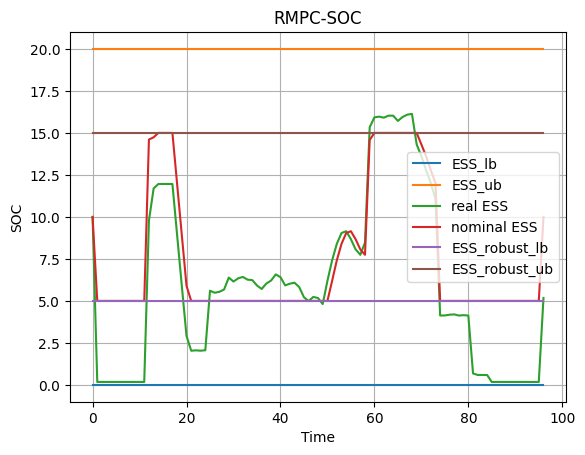

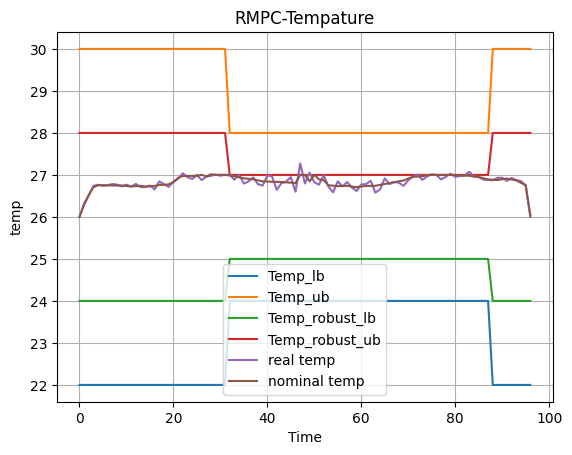

In [22]:
# This function is standard Robust MPC
def robust_mpc(t0, ess0, tau0, spare = 0.2):
    # t0 should be choosen from 0-96
    tau_forecast, p_forecast, _, _, _ = scen_generation(t0)
    H = tau_forecast.shape[0]
    # Optimization variables setup
    p_buy_hat = cp.Variable(H, nonneg=True)
    p_pvc_hat = cp.Variable(H, nonneg=True)
    p_ch_hat = cp.Variable(H, nonneg=True)
    p_dis_hat = cp.Variable(H, nonneg=True)
    p_ess_hat = cp.Variable(H)
    p_hvac_hat = cp.Variable(H)
    p_heat_hat = cp.Variable(H, nonneg=True)
    p_cool_hat = cp.Variable(H, nonneg=True)
    tau_hat = cp.Variable(H)
    ess_hat = cp.Variable(H)
    # Objective Setup
    C_buy = c_buy[t0:t0+T_c] @ p_buy_hat
    C_deg = c_deg * (eta_ch * cp.sum(p_ch_hat) + cp.sum(p_dis_hat) / eta_dch)
    C_cur = c_cur * cp.sum(p_pvc_hat)
    C_ther = c_ther * cp.norm(tau_hat - tau_ref, 2) ** 2
    obj = cp.Minimize(C_buy + C_deg + C_cur + C_ther)
    constraints = []
    # Constraints Setup
    # ESS dynamics
    for t in range(H):
        if t == 0:
            constraints.append(ess_hat[t] == ess0 + eta_ch * p_ch_hat[t] - p_dis_hat[t] / eta_dch)
        else:
            constraints.append(ess_hat[t] == ess_hat[t-1] + eta_ch * p_ch_hat[t] - p_dis_hat[t] / eta_dch)
        if t + t0 == 24 * 4 - 1:
            constraints.append(ess_hat[t] == ess_int)
    constraints.append(ess_hat <= ess_max - spare * (ess_max-ess_min))
    constraints.append(ess_hat >= ess_min + spare * (ess_max-ess_min))
    constraints.append(p_ch_hat <= p_ch_max)
    constraints.append(p_dis_hat <= p_dis_max)
    constraints.append(p_ess_hat == p_ch_hat - p_dis_hat)
    # Thermal Dynamics
    for t in range(H):
        if t == 0:
            constraints.append(tau_hat[t] == tau0 + gama1 * (tau_forecast[t] - tau0) + gama2 * (p_heat_hat[t] - p_cool_hat[t]))
        else:
            constraints.append(tau_hat[t] == tau_hat[t-1] + gama1 * (tau_forecast[t] - tau_hat[t-1]) + gama2 * (p_heat_hat[t] - p_cool_hat[t]))
        if t + t0 == 24 * 4 - 1:
            constraints.append(tau_hat[t] == tau_ini)
    constraints.append(tau_hat <= tau_max[t0:t0+H] - spare * (tau_max[t0:t0+H] - tau_min[t0:t0+H]))
    constraints.append(tau_hat >= tau_min[t0:t0+H] + spare * (tau_max[t0:t0+H] - tau_min[t0:t0+H]))
    constraints.append(p_heat_hat <= p_hvac_max)
    constraints.append(p_cool_hat <= p_hvac_max)
    constraints.append(p_hvac_hat == p_heat_hat + p_cool_hat) 
    # power balance
    constraints.append(p_forecast + p_ess_hat + p_hvac_hat + p_pvc_hat == p_buy_hat)
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.GUROBI)
    print(f"Current time: {curr_t}. Problem Status: {prob.status}")
    forecasts = [p_forecast[0], tau_forecast[0]]
    controls = [p_buy_hat.value[0], p_pvc_hat.value[0]]
    ther_ps = [p_hvac_hat.value[0], p_heat_hat.value[0], p_cool_hat.value[0]]
    ther_taus = [tau_hat.value[0]]
    ess_ps = [p_ess_hat.value[0], p_ch_hat.value[0], p_dis_hat.value[0]]
    ess_esss = [ess_hat.value[0]]
    return forecasts, controls, ther_ps, ther_taus, ess_ps, ess_esss


t_start, t_end = 0, 4 * 24 - 1
real_temp = select_data[y_temp_features].iloc[-24*4:].to_numpy()
real_pv = select_data[y_pv_features].iloc[-24*4:].to_numpy()
real_load = select_load_data[y_load_features].iloc[-24*4:].to_numpy() / 5e3
real_net_load = real_load - real_pv
ess_list = [ess_int]
nom_ess_list = [ess_int]
tau_list = [tau_ini]
nom_tau_list = [tau_ini]
before_tau_list = [tau_ini]
before_ess_list = [ess_int]
start_time = time.time()
cost_list = []
curr_ess = ess_int
curr_tau = tau_ini
total_penalty = 0
spare_coefficient = 0.25
for curr_t in range(t_start, t_end+1):
    forecasts, controls, ther_ps, ther_taus, ess_ps, ess_esss = robust_mpc(curr_t, curr_ess, curr_tau, spare=spare_coefficient)
    forecast_net_load, forecast_tau = forecasts
    p_buy, p_pvc = controls
    p_hvac, p_heat, p_cool = ther_ps
    tau = ther_taus[0]
    p_ess, p_ch, p_dis = ess_ps
    ess = ess_esss[0]
    elec_error = (real_net_load[curr_t] - forecast_net_load) * www
    tau_error = (real_temp[curr_t] - forecast_tau) * www
    # Update system disturbance according to the disturbances
    curr_tau = curr_tau + gama1 * (forecast_tau - curr_tau) + gama2 * (p_heat - p_cool) + tau_error * gama1
    curr_ess = curr_ess + eta_ch * p_ch - p_dis / eta_dch 

    if elec_error <= 0:
        curr_ess += elec_error / eta_dch
    else:
        curr_ess += elec_error * eta_ch 
    before_ess_list.append(curr_ess)
    before_tau_list.append(curr_tau)
    # ESS correction
    if curr_ess >= ess_max:
        total_penalty += c_cur * (curr_ess - ess_max)
        curr_ess = ess_max
    elif curr_ess < ess_min:
        total_penalty += c_pen[curr_t] * (ess_min - curr_ess)
        curr_ess = ess_min
    else:
        curr_ess = curr_ess.item()
    # Temp correction
    if curr_tau >= tau_max[curr_t]:
        total_penalty += c_pen[curr_t] * (curr_tau - tau_max[curr_t]) / gama2
        curr_tau = tau_max[curr_t]
    elif curr_tau < tau_min[curr_t]:
        total_penalty += c_pen[curr_t] * (tau_min[curr_t] - curr_tau) / gama2
        curr_tau = tau_min[curr_t]
    else:
        curr_tau = curr_tau.item()


    ess_list.append(curr_ess)
    tau_list.append(curr_tau)
    nom_ess_list.append(ess)
    nom_tau_list.append(tau)
    # Update the current costs
    curr_C_buy = c_buy[curr_t] * p_buy
    curr_C_deg = c_deg * (p_ch * eta_ch + p_dis / eta_dch)
    curr_C_cur = c_cur * p_pvc
    curr_C_ther = c_ther * (curr_tau - tau_ref) ** 2
    cost_list.append(curr_C_buy + curr_C_deg + curr_C_cur + curr_C_ther)

end_time = time.time()
print(f"Running Time: {end_time - start_time}")
print(f"Total Cost: {np.sum(cost_list) + total_penalty}")
print(f"Total operational cost: {np.sum(cost_list)}")
print(f"Total penalty: {total_penalty}")
# plot the system states and control actions
# figure on ess: 
plt.plot([ess_min for _ in range(len(ess_list))], label='ESS_lb')
plt.plot([ess_max for _ in range(len(ess_list))], label='ESS_ub')
plt.plot(ess_list, label='real ESS')
plt.plot(nom_ess_list, label='nominal ESS')
plt.plot([ess_min + spare_coefficient*(ess_max-ess_min) for _ in range(len(ess_list))], label='ESS_robust_lb')
plt.plot([ess_max - spare_coefficient*(ess_max-ess_min) for _ in range(len(ess_list))], label='ESS_robust_ub')
plt.xlabel('Time')
plt.ylabel('SOC')
plt.title('RMPC-SOC')
plt.legend()
plt.grid(True)
plt.show()
# figure on temp:
# plt.plot([tau_min for _ in range(len(ess_list))], label='Temp lb')
# plt.plot([tau_max for _ in range(len(ess_list))], label='Temp ub')
plt.plot(tau_min[:len(tau_list)], label='Temp_lb')
plt.plot(tau_max[:len(tau_list)], label='Temp_ub')
plt.plot(tau_min[:len(tau_list)] + spare_coefficient*(tau_max[:len(tau_list)]-tau_min[:len(tau_list)]), label='Temp_robust_lb')
plt.plot(tau_max[:len(tau_list)] - spare_coefficient*(tau_max[:len(tau_list)]-tau_min[:len(tau_list)]), label='Temp_robust_ub')
plt.plot(tau_list, label='real temp')
plt.plot(nom_tau_list, label='nominal temp')
plt.xlabel('Time')
plt.ylabel('temp')
plt.title('RMPC-Tempature')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
data_dict = {
    'ESS Upper Bound': [ess_max for i in range(97)],
    'ESS Lower Bound': [ess_min for i in range(97)],
    'ESS Robust Upper Bound': [ess_max - spare_coefficient*(ess_max-ess_min) for _ in range(len(ess_list))],
    'ESS Robust Lower Bound': [ess_min + spare_coefficient*(ess_max-ess_min) for _ in range(len(ess_list))],
    'ESS nominal': nom_ess_list,
    'ESS actual': ess_list,
    'ESS before': before_ess_list,
    'Temp Upper Bound': tau_max[:97],
    'Temp Lower Bound': tau_min[:97],
    'Temp Robust Upper Bound': tau_max[:len(tau_list)] - spare_coefficient*(tau_max[:len(tau_list)]-tau_min[:len(tau_list)]),
    'Temp Robust Lower Bound': tau_min[:len(tau_list)] + spare_coefficient*(tau_max[:len(tau_list)]-tau_min[:len(tau_list)]),
    'Temp nominal': nom_tau_list,
    'Temp actual': tau_list,
    'Temp before': before_tau_list,
}
df = pd.DataFrame(data_dict)
cols_to_clean = ['ESS before', 'Temp before']
for col in cols_to_clean:
    df[col] = df[col].apply(extract_scalar)
df.to_csv(f"numerical results/0706RMPC.csv", index=False)